# **Customer Churn Risk Prediction Project**

**Business Context**:
In the SaaS industry, customer retention is a critical driver of revenue
growth. Unlike traditional businesses, SaaS companies rely on recurring
revenue, making churn directly tied to long-term financial sustainability.
Industry research suggests that acquiring a new customer costs 5-7x more
than retaining an existing one, making early churn detection one of the
highest-value problems a SaaS business can solve.

**Problem Statement**:
This project aims to identify customers at risk of churning before
they disengage, enabling proactive retention efforts that protect recurring
revenue and maximize customer lifetime value. Using a dataset of
10,000 customers, the goal is to build a reliable early warning system
that translates behavioral product signals into actionable retention strategies.

**Success Metrics**:
- Model achieves >0.85 AUC-ROC on held-out test data
- Identifies >90% of at-risk customers before they churn (recall)
- Business modeling demonstrates measurable recurring revenue recovery potential

**Dataset**:
10,000 customer records with behavioral features including
product engagement (app opens), purchase recency, email interaction,
discount usage, support activity, and spending patterns, metrics commonly
tracked in modern SaaS platforms.

**Note**: This dataset is synthetic and designed to simulate a SaaS customer
base. While the data is fictional, the methodology and findings are
directly applicable to real-world SaaS retention challenges.

Approach:
1. Data Cleaning & Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering & Selection
4. Class Imbalance Handling (SMOTE)
5. Model Training & Comparison (5 Models)
6. Model Evaluation (ROC, Precision-Recall, Confusion Matrix)
7. Threshold Optimization
8. Business Impact Modeling
9. Recommendations & Action Plan

# **Dataset Preview**

This dataset contains 10,000 rows of customer subscription data, with the following columns:

| Column                     | Type         | Description                                                              |
|----------------------------|--------------|--------------------------------------------------------------------------|
| `customer_id`              | Categorical  | Unique ID                                                                |
| `age`                      | Numeric      | Age of customer                                                          |
| `gender`                   | Categorical  | M / F / Other                                                            |
| `city`                     | Categorical  | City label                                                               |
| `signup_days_ago`          | Numeric      | Days since customer signed up                                            |
| `total_spend`              | Numeric      | Total lifetime spend                                                     |
| `avg_order_value`          | Numeric      | Average order size                                                       |
| `purchase_frequency`       | Numeric      | Purchases per month                                                      |
| `time_since_last_purchase` | Numeric      | Days since last transaction                                              |
| `most_frequent_category`   | Categorical  | Top product category                                                     |
| `customer_support_calls`   | Numeric      | Number of times they contacted support                                   |
| `discount_usage_rate`      | Numeric      | % of purchases made with a discount                                      |
| `device_type`              | Categorical  | Desktop / Mobile / Tablet                                                |
| `preferred_purchase_time`  | Categorical  | Morning / Afternoon / Evening                                            |
| `email_open_rate`          | Numeric      | % of marketing emails opened                                             |
| `app_opens_last_30d`       | Numeric      | How many times the app was opened in the last 30 days                    |
| `engagement_score`         | Numeric      | Measures recent customer activity (0–100) based on app, email, and purchases |


# **Tools Used**

- **SQL (Google BigQuery)** for initial exploratory data analysis (EDA)
- **Python (Google Colab)** for model building, feature engineering, and evaluation
- **Pandas & NumPy** for data manipulation
- **Seaborn & Matplotlib** for data visualization
- **Scikit-learn** for preprocessing, modeling, and performance metrics
- **XGBoost** for advanced modeling and hyperparameter tuning
- **Power BI** for the creation of a summary dashboard

---

# **Part I: Project Prep**

This section initializes the project environment by importing necessary libraries, suppressing warnings, and setting up basic notebook configurations. This ensures everything runs smoothly before the data is loaded.

## **Importing Modules, Model Packaging**

In [1]:
# core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

## **Data Loading**



In [2]:
# selecting data file
from google.colab import files
uploaded = files.upload()

Saving customer_engagement.csv to customer_engagement (2).csv


In [3]:
# setting options to show every column when running df.head()
pd.set_option("display.max_columns", None)

# reading in data, displaying first 5 rows
df = pd.read_csv("customer_engagement.csv")
df.head()

,customer_id,age,gender,city,signup_days_ago,total_spend,avg_order_value,purchase_frequency,time_since_last_purchase,most_frequent_category,customer_support_calls,discount_usage_rate,device_type,preferred_purchase_time,email_open_rate,app_opens_last_30d,engagement_score
0,CUST_00000,56,Other,Chicago,1334,1022.57,90.86,1.28,40,Home,2,0.50,Tablet,Morning,0.69,12,45.31
1,CUST_00001,69,Female,San Jose,755,69.08,74.45,1.47,91,Clothing,0,0.04,Desktop,Evening,0.85,7,56.58
2,CUST_00002,46,Female,Phoenix,1075,57.18,65.73,3.90,113,Home,1,0.30,Desktop,Evening,0.66,14,52.96
3,CUST_00003,32,Male,Jacksonville,495,166.14,96.83,3.37,108,Electronics,1,0.41,Mobile,Morning,0.83,8,25.65
4,CUST_00004,60,Female,Fort Worth,409,447.80,51.38,1.12,134,Sports,0,0.67,Mobile,Evening,0.77,5,33.05


---

# **Part II: Problem Framing**

In many real-world datasets, a confirmed churn event (such as account cancellation) is not always available. In this project, churn is therefore approximated using a behavioral engagement proxy.

Customers with an engagement score below 30 are classified as being at elevated retention risk. This threshold represents a level of declining activity that signals potential disengagement.

By defining churn risk using an engagement-based proxy, the analysis simulates an early warning system that identifies customers whose behavioral patterns suggest they may soon stop using the platform.

Because the churn label is derived from engagement behavior, models that include the engagement score will naturally achieve extremely high performance and are treated as benchmark models rather than realistic deployment scenarios.

In [4]:
# identifying customers with an engagement_score < 30
df["churn"] = (df["engagement_score"] < 30).astype(int)
df.head()

,customer_id,age,gender,city,signup_days_ago,total_spend,avg_order_value,purchase_frequency,time_since_last_purchase,most_frequent_category,customer_support_calls,discount_usage_rate,device_type,preferred_purchase_time,email_open_rate,app_opens_last_30d,engagement_score,churn
0,CUST_00000,56,Other,Chicago,1334,1022.57,90.86,1.28,40,Home,2,0.50,Tablet,Morning,0.69,12,45.31,0
1,CUST_00001,69,Female,San Jose,755,69.08,74.45,1.47,91,Clothing,0,0.04,Desktop,Evening,0.85,7,56.58,0
2,CUST_00002,46,Female,Phoenix,1075,57.18,65.73,3.90,113,Home,1,0.30,Desktop,Evening,0.66,14,52.96,0
3,CUST_00003,32,Male,Jacksonville,495,166.14,96.83,3.37,108,Electronics,1,0.41,Mobile,Morning,0.83,8,25.65,1
4,CUST_00004,60,Female,Fort Worth,409,447.80,51.38,1.12,134,Sports,0,0.67,Mobile,Evening,0.77,5,33.05,0


---

# **Part III: Data Cleaning**

Check for missing values and duplicates, inspect data types and cardinality, review class balance, and remove irrelevant columns.


In [5]:
# check for null values
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
city,0
signup_days_ago,0
total_spend,0
avg_order_value,0
purchase_frequency,0
time_since_last_purchase,0
most_frequent_category,0


## **Data Quality Issue**

During initial data exploration, two data quality issues were identified:

**Negative Purchase Frequency (228 rows):** Purchase frequency represents
the number of transactions a customer makes per year and cannot logically
be negative. These values likely reflect data entry errors or system
anomalies and were removed from the dataset.

**Negative Average Order Value (14 rows):** Average order value represents
the mean transaction amount per customer and cannot logically be negative.
These values likely reflect returned orders recorded incorrectly and were
removed from the dataset.

Both issues represent a combined removal of less than 3% of total records,
preserving the integrity of the dataset without meaningful loss of analytical
coverage.

In [6]:
# showing how many records of purchase_frequency are < 0
print(df[df["purchase_frequency"] < 0])

     customer_id  age  gender          city  signup_days_ago  total_spend  \
24    CUST_00024   38    Male     San Diego             1751       634.44   
54    CUST_00054   19   Other    Fort Worth               18      1491.26   
93    CUST_00093   41   Other        Dallas             1319        79.94   
155   CUST_00155   30  Female      New York              116       555.84   
175   CUST_00175   68  Female   San Antonio             1584       151.85   
...          ...  ...     ...           ...              ...          ...   
9814  CUST_09814   23   Other     San Diego             1092       379.20   
9832  CUST_09832   51    Male  Jacksonville             1634       129.88   
9854  CUST_09854   42    Male  Jacksonville              895        91.44   
9949  CUST_09949   68  Female        Austin             1384       720.67   
9982  CUST_09982   47   Other      New York              796       178.89   

      avg_order_value  purchase_frequency  time_since_last_purchase  \
24  

In [7]:
# drop rows with negative purchase frequency
df = df[df['purchase_frequency'] >= 0]

# verify
print(f"Rows removed: {10000 - len(df)}")
print(f"Remaining rows: {len(df)}")

Rows removed: 228
Remaining rows: 9772


In [8]:
# checking average order values below 0
print(df[df["avg_order_value"] < 0])

     customer_id  age  gender          city  signup_days_ago  total_spend  \
827   CUST_00827   45    Male  Philadelphia              799       492.73   
3122  CUST_03122   24   Other       Chicago              475       326.88   
3394  CUST_03394   64    Male      Columbus             1271       807.37   
3431  CUST_03431   29   Other     San Diego             1205       210.03   
3441  CUST_03441   21   Other     Charlotte             1407       271.46   
4408  CUST_04408   20    Male        Austin              412       120.45   
5623  CUST_05623   37    Male       Houston              990       431.56   
6041  CUST_06041   65   Other    Fort Worth             1512         4.78   
6892  CUST_06892   61   Other  Jacksonville             1116        25.14   
7284  CUST_07284   51  Female        Dallas             1118         7.61   
7695  CUST_07695   64   Other   Los Angeles              690       624.03   
8590  CUST_08590   23    Male    Fort Worth              599       215.53   

In [9]:
# drop rows with negative average order value
df = df[df["avg_order_value"] >= 0]

# verify
print(f"Rows removed: {9772 - len(df)}")
print(f"Remaining rows: {len(df)}")

Rows removed: 14
Remaining rows: 9758


In [10]:
# checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# viewing datatypes
df.dtypes

,0
customer_id,object
age,int64
gender,object
city,object
signup_days_ago,int64
total_spend,float64
avg_order_value,float64
purchase_frequency,float64
time_since_last_purchase,int64
most_frequent_category,object


In [12]:
# checking cardinality
df.nunique().sort_values(ascending = False)

,0
customer_id,9758
total_spend,9286
avg_order_value,6064
engagement_score,4668
signup_days_ago,1817
purchase_frequency,484
time_since_last_purchase,180
email_open_rate,90
discount_usage_rate,87
age,52


- Numeric columns like `total_spend` and `email_open_rate` have high cardinality.
  Scaling was considered but not applied as tree-based models (XGBoost,
  Random Forest) are scale-invariant.
- Categorical columns like `gender`, `device_type`, and `preferred_purchase_time` have low cardinality and were one-hot encoded.
- High-cardinality categoricals like `city` (15 unique values) were one-hot
  encoded and later dropped due to negligible correlation with churn (<0.02).

Understanding cardinality helps choose the right encoding strategy and
avoid unnecessary dimensionality.

---

# **Part IV: Exploratory Analysis**

Explore how churn varies by demographic and behavioral features. These visuals help uncover potential drivers of churn.


In [13]:
# set chart style throughout the workflow
sns.set(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## **Engagement Score Distribution**

This shows how engagement scores are distributed across the customer base and helps validate the churn threshold.

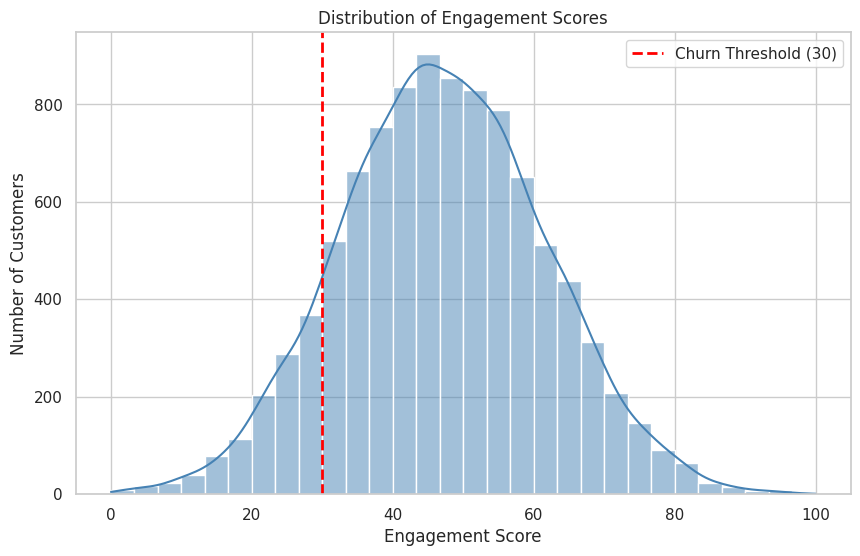

In [14]:
# histogram of engagement score
plt.figure(figsize=(10, 6))
sns.histplot(df["engagement_score"], bins = 30, kde = True, color = "steelblue")

# add churn threshold line
plt.axvline(x = 30, color = "red", linestyle = "--", linewidth = 2, label = "Churn Threshold (30)")

# labels
plt.title("Distribution of Engagement Scores")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Customers")
plt.legend()
plt.grid(True)
plt.show()

This histogram shows the distribution of engagement scores across all customers. The red dashed line marks the churn threshold at a score of 30. Customers at or below this threshold show elevated risk, highlighting a clear separation between engaged and disengaged users.

## **Behavioral Churn Indicators**


In [15]:
# churn rate by time since last purchase
print("Churn Rate by Time Since Last Purchase:")
display(df.groupby(pd.qcut(df["time_since_last_purchase"], q = 3))["churn"].mean().to_frame("churn_rate").apply(lambda x: (x * 100).round(1).astype(str) + "%"))

# churn rate by app opens
print("\nChurn Rate by App Opens (Last 30 Days):")
display(df.groupby(pd.qcut(df["app_opens_last_30d"], q = 3))["churn"].mean().to_frame("churn_rate").apply(lambda x: (x * 100).round(1).astype(str) + "%"))

# churn rate by purchase frequency
print("\nChurn Rate by Purchase Frequency:")
display(df.groupby(pd.qcut(df["purchase_frequency"], q = 3))["churn"].mean().to_frame("churn_rate").apply(lambda x: (x * 100).round(1).astype(str) + "%"))

# churn rate by email_open_rate
print("\nChurn Rate by Email Open Rate:")
display(df.groupby(pd.qcut(df["email_open_rate"], q = 3))["churn"].mean().to_frame("churn_rate").apply(lambda x: (x * 100).round(1).astype(str) + "%"))

Churn Rate by Time Since Last Purchase:


,churn_rate
time_since_last_purchase,
"(-0.001, 59.0]",3.7%
"(59.0, 120.0]",10.4%
"(120.0, 179.0]",21.0%



Churn Rate by App Opens (Last 30 Days):


,churn_rate
app_opens_last_30d,
"(-0.001, 9.0]",16.9%
"(9.0, 11.0]",9.6%
"(11.0, 22.0]",5.4%



Churn Rate by Purchase Frequency:


,churn_rate
purchase_frequency,
"(-0.001, 1.61]",16.8%
"(1.61, 2.44]",11.4%
"(2.44, 5.55]",6.7%



Churn Rate by Email Open Rate:


,churn_rate
email_open_rate,
"(0.109, 0.66]",16.9%
"(0.66, 0.81]",11.0%
"(0.81, 1.0]",6.5%


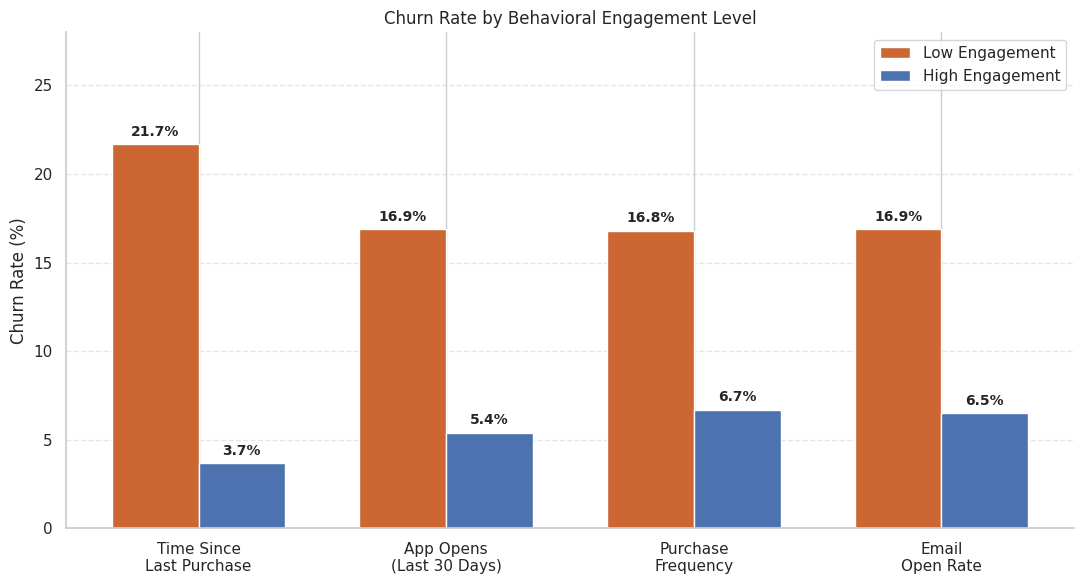

In [16]:
# visualizing the above tables for the write-up

# data from above tables
features = ['Time Since\nLast Purchase', 'App Opens\n(Last 30 Days)', 'Purchase\nFrequency', 'Email\nOpen Rate']
low_engagement = [21.7, 16.9, 16.8, 16.9]
high_engagement = [3.7, 5.4, 6.7, 6.5]

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, low_engagement, width, label = 'Low Engagement', color = '#CC6633')
bars2 = ax.bar(x + width/2, high_engagement, width, label = 'High Engagement', color = '#4C72B0')

# data labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height()}%', ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height()}%', ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Behavioral Engagement Level')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylim(0, 28)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle = '--', alpha = 0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

These tables reveal clear behavioral patterns across four key features.

 - Customers who haven't purchased in over **120 days churn at a rate of 21.7%, nearly 6x higher than those who purchased within the last 60 days (3.7%)**, making purchase recency the strongest behavioral signal of churn risk.

 - App engagement tells a similar story in reverse; customers with **fewer than 9 app opens in the last 30 days churn at 16.9%, compared to just 5.4% for those with 11 or more opens**, suggesting that declining app usage is an early warning sign of disengagement.

 - Purchase frequency follows the same pattern, with **low-frequency buyers
churning at 16.8% versus 6.7% for the most active purchasers.**

 - Customers who open **less than 66% of marketing emails received** churn at **16.9%**, which is **2.6x higher than customers who open between 81% and 100% of marketing emails**, indicating that multiple unread emails(or emails that were marked as read without actually reading it) is a key indicator of churn.


Across all four features, the trend is consistent; customers showing
declining behavioral engagement are significantly more likely to churn,
reinforcing their value as predictors in the model.



## **Churn Distribution**

Basic class balance check to see how many customers are labeled as churned vs retained.


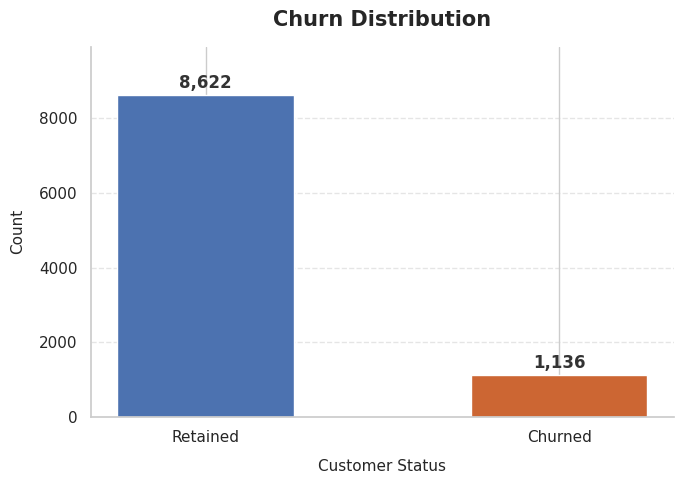

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ["#4C72B0", "#CC6633"]
churn_counts = df["churn"].value_counts().sort_index()
bars = ax.bar(["Retained", "Churned"], churn_counts.values, color = colors, width = 0.5, edgecolor = "white")

# data labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{int(height):,}",
        ha = "center", va = "bottom", fontsize = 12, fontweight = "bold", color = "#333333"
    )

# styling
ax.set_title("Churn Distribution", fontsize = 15, fontweight = "bold", pad = 15)
ax.set_xlabel("Customer Status", fontsize = 11, labelpad = 10)
ax.set_ylabel("Count", fontsize = 11, labelpad = 10)
ax.set_ylim(0, churn_counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle = "--", alpha = 0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

> The dataset contains **8,622 retained customers** and **1,136 churners**, meaning roughly 1 in 8 customers left. This class imbalance is worth keeping in mind when evaluating model performance, as a naive model could score well simply by predicting "retained" for everyone.


## **Churn by Gender**

Explore whether there's a noticeable churn pattern by gender.

*Note: Although churn by gender was analyzed, the correlation with churn is negligible(<0.02), therefore it was omitted from modeling.*


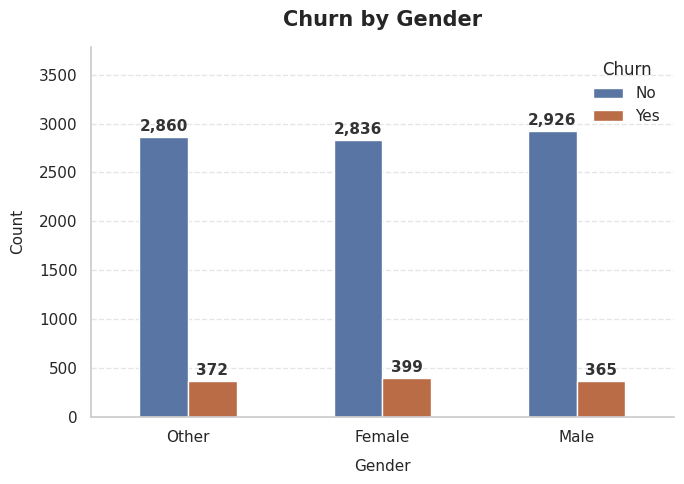

In [18]:
fig, ax = plt.subplots(figsize = (7, 5))

sns.countplot(
    x = "gender",
    hue = "churn",
    data = df,
    palette = ["#4C72B0", "#CC6633"],
    width = 0.5,
    edgecolor = "white",
    ax = ax
)

# data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 30,
            f"{int(height):,}",
            ha = "center", va = "bottom", fontsize = 11, fontweight = "bold", color = "#333333"
        )

# styling
ax.set_title("Churn by Gender", fontsize = 15, fontweight = "bold", pad = 15)
ax.set_xlabel("Gender", fontsize = 11, labelpad = 10)
ax.set_ylabel("Count", fontsize = 11, labelpad = 10)
ax.set_ylim(0, df["gender"].value_counts().max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle = "--", alpha = 0.5)
ax.set_axisbelow(True)
ax.legend(title = "Churn", labels = ["No", "Yes"], frameon = False)

plt.tight_layout()
plt.show()

Churn rates are remarkably consistent across all three gender groups, with churned customers ranging narrowly from 365 to 399 out of an average of 2,874 retained in each group. Gender does not appear to be a meaningful predictor of churn in this dataset.



## **Churn by City**

Visualize churn distribution across the top 10 cities by customer count.

*Note: Although churn by city was analyzed, the correlation with churn is negligible (<0.02), therefore it was omitted from modeling.*

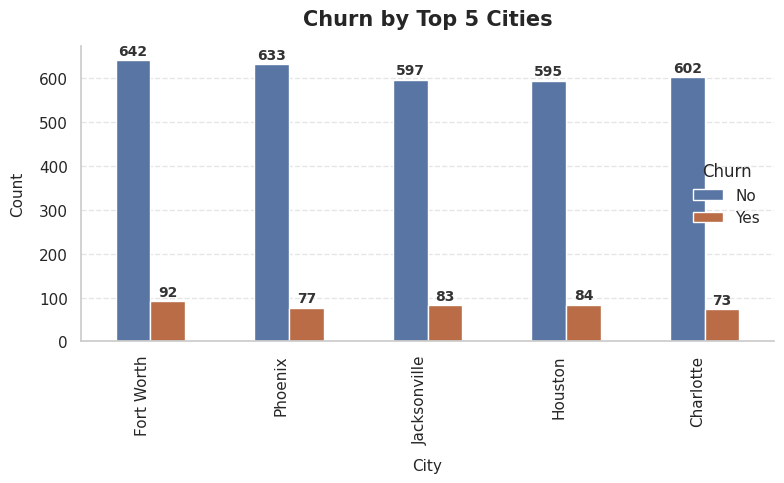

In [19]:
# filter for top 5 cities by total customer count
top_cities = df["city"].value_counts().nlargest(5).index
df_top_cities = df[df["city"].isin(top_cities)]

# sort city order by total count
city_order = (
    df_top_cities.groupby("city")
    .size()
    .sort_values(ascending = False)
    .index
)

fig, ax = plt.subplots(figsize = (8, 5))

sns.countplot(
    x = "city",
    hue = "churn",
    data = df_top_cities,
    order = city_order,
    palette = ["#4C72B0", "#CC6633"],
    width = 0.5,
    edgecolor = "white",
    ax = ax
)

# data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 5,
            f"{int(height):,}",
            ha = "center", va = "bottom", fontsize = 10, fontweight = "bold", color = "#333333"
        )

# styling
ax.set_title("Churn by Top 5 Cities", fontsize = 15, fontweight = "bold", pad = 15)
ax.set_xlabel("City", fontsize = 11, labelpad = 10)
ax.set_ylabel("Count", fontsize = 11, labelpad = 10)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle = "--", alpha = 0.5)
ax.set_axisbelow(True)
ax.legend(title = "Churn", labels = ["No", "Yes"], frameon = False)
plt.xticks(rotation = 90, ha = "right")

plt.tight_layout()
plt.show()

Similar to gender, churn is consistent across the top 5 cities based on churn, signaling that location is unlikely to be a strong predictor for customer churn.


### **Distributions by Churn**

Look at how numeric features vary between churned and retained customers.


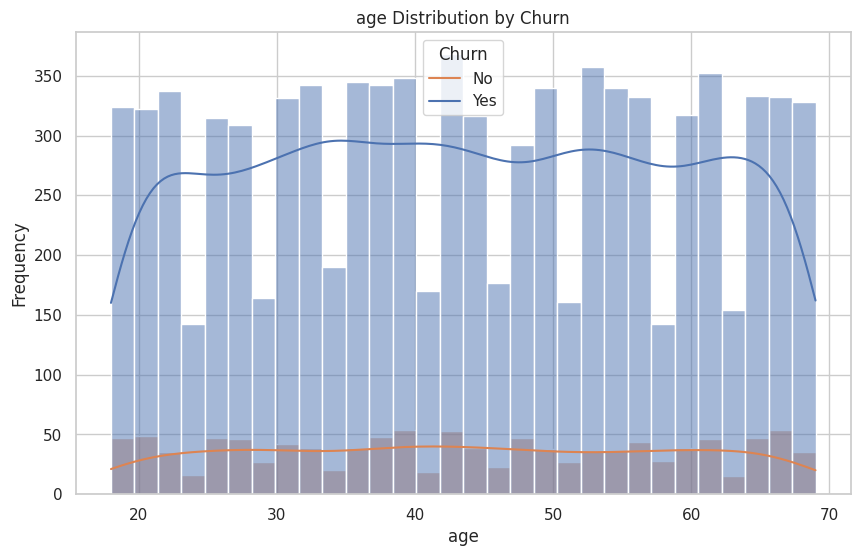

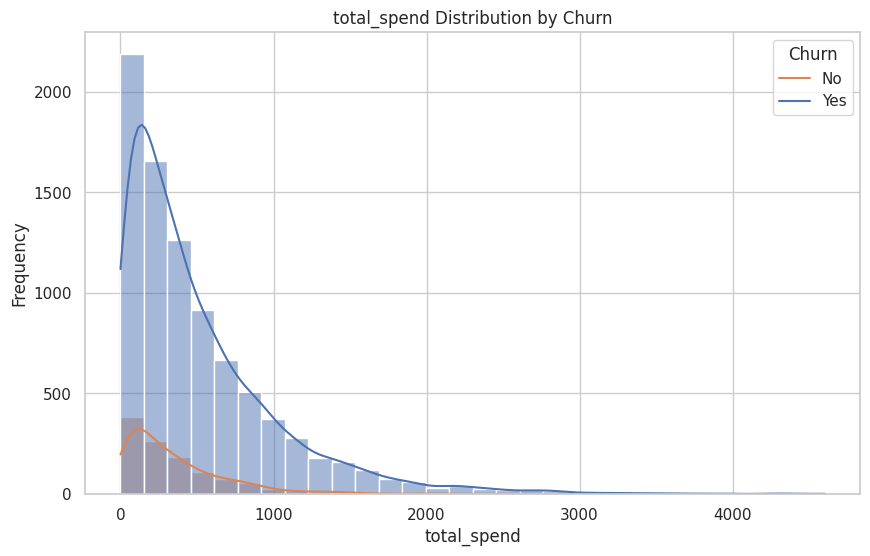

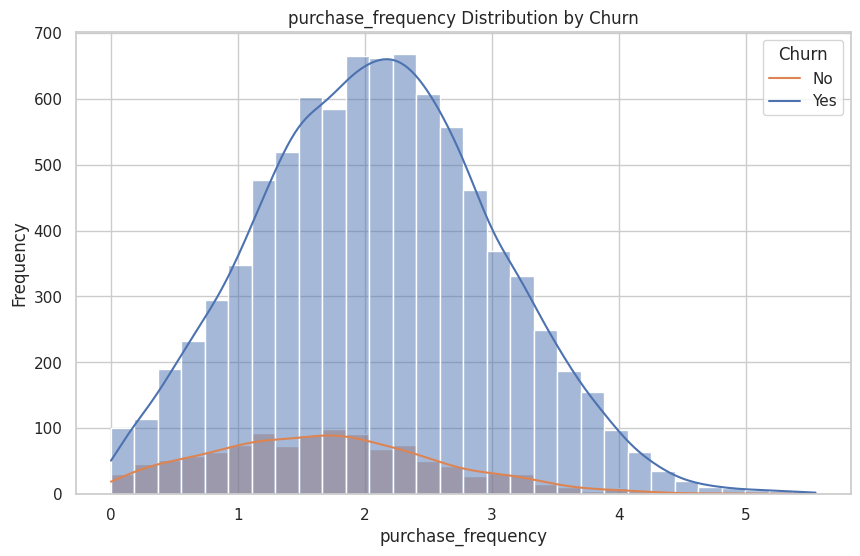

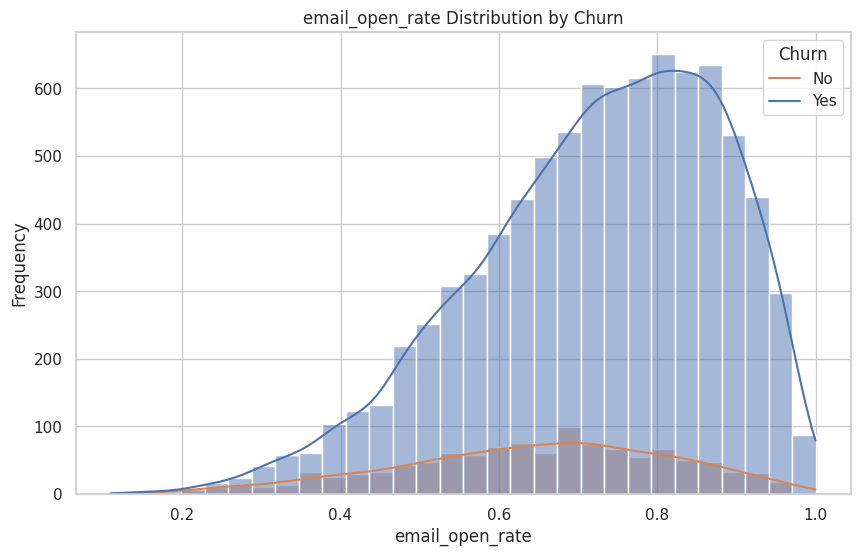

In [20]:
# distribution of numeric columns by churn
num_cols = ["age", "total_spend", "purchase_frequency", "email_open_rate"]
for col in num_cols:
    plt.figure()
    sns.histplot(data = df, x = col, hue = "churn", kde = True, bins = 30)
    plt.title(f"{col} Distribution by Churn")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend(title = "Churn", labels = ["No", "Yes"])
    plt.show()

These plots highlight how behavioral features differ between churned and retained customers. For example, churners often have lower spend and lower app usage.



### **Boxplots of Key Metrics by Churn**

Identify median and outlier behavior by churn class for core numeric variables.


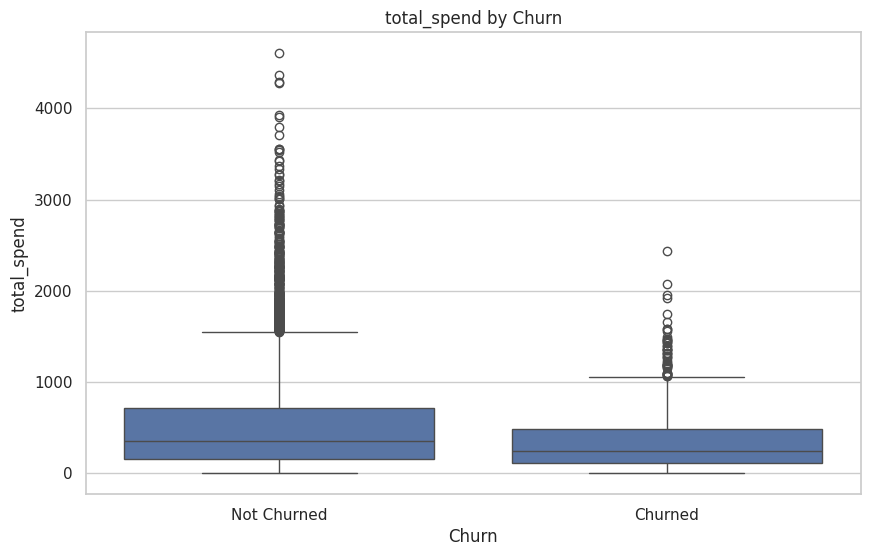

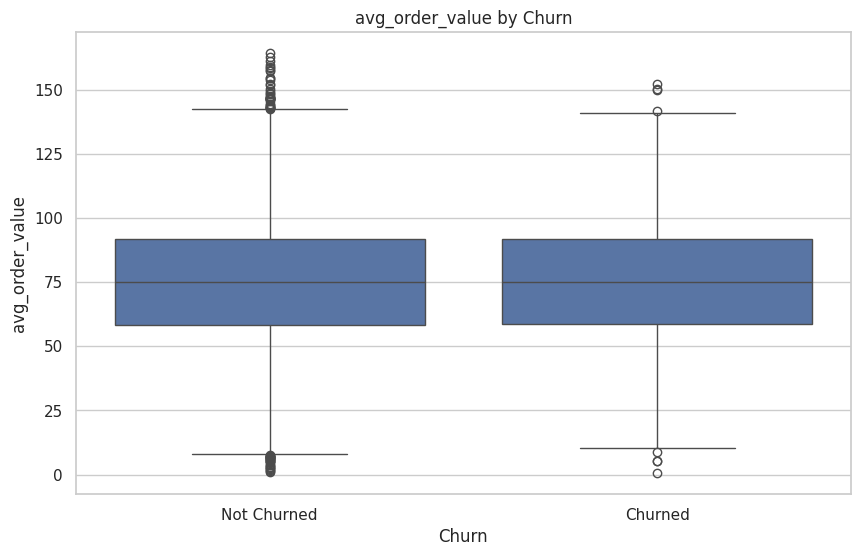

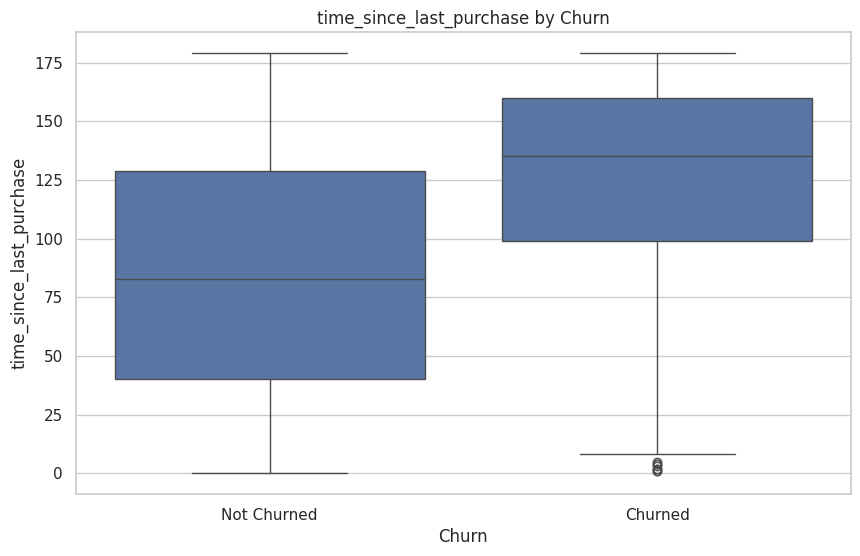

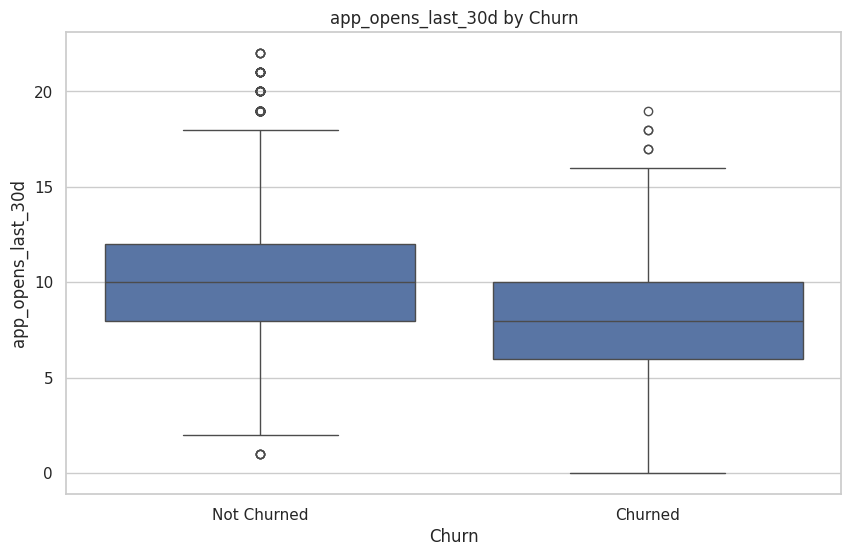

In [21]:
# boxplots for churn vs. numeric columns
box_cols = ["total_spend", "avg_order_value", "time_since_last_purchase", "app_opens_last_30d"]
for col in box_cols:
    plt.figure()
    sns.boxplot(x = "churn", y = col, data = df)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Not Churned", "Churned"])
    plt.show()

Boxplots help visualize medians and outliers. Customers who churn tend to have fewer app opens and lower average order values.


### **Feature Correlation**

Check correlations between numeric features to identify strong predictors of churn or redundancy.


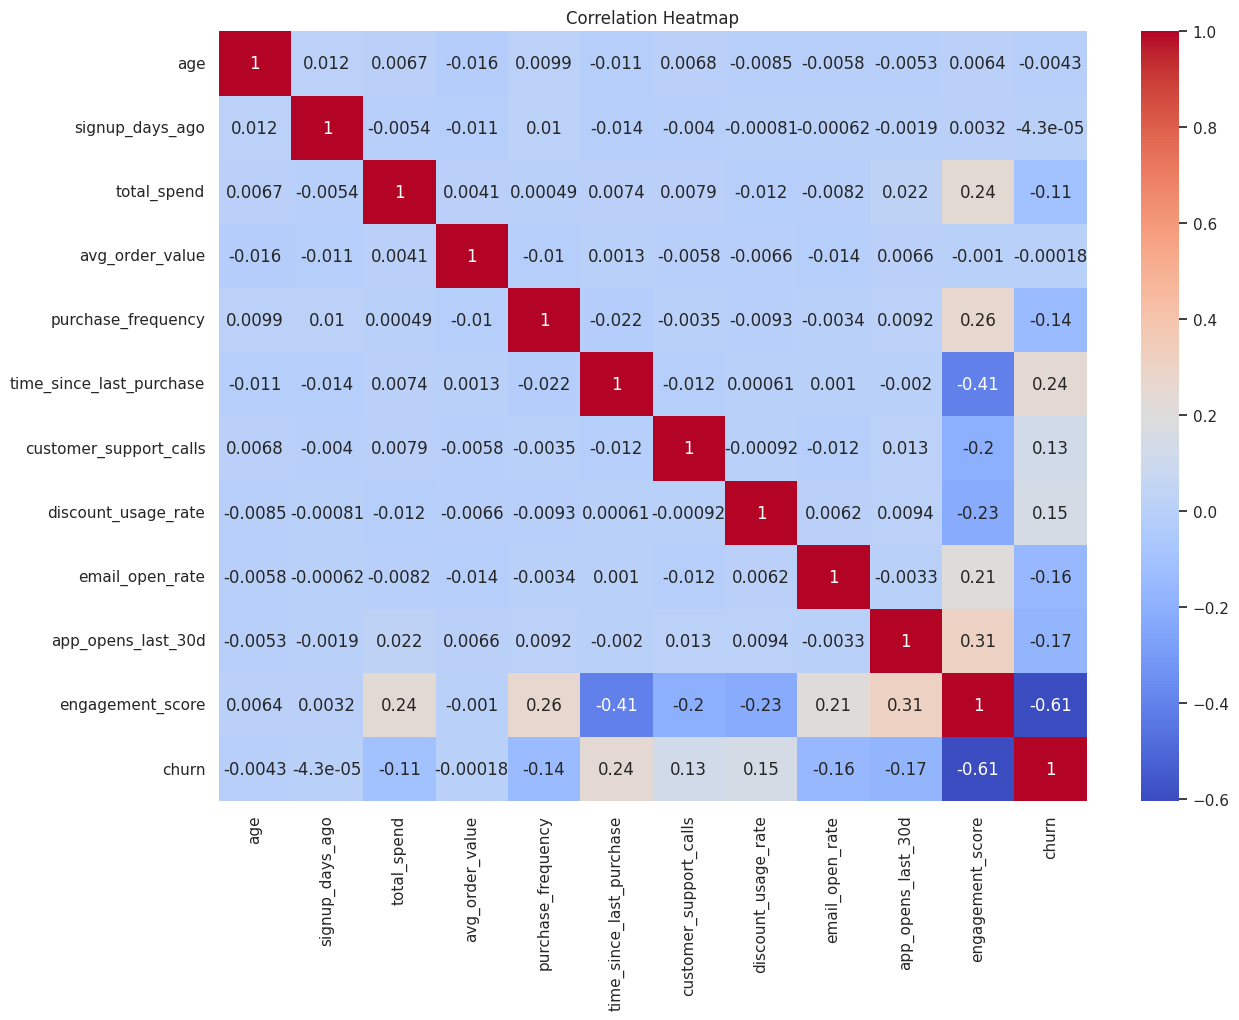

In [22]:
# correlation heatmap
plt.figure(figsize = (14, 10))
corr = df.select_dtypes(include = ["int64", "float64"]).corr()
sns.heatmap(corr, cmap = "coolwarm", annot = True)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reveals the linear relationships between all numeric features and the target variable, churn.

`engagement_score` shows the strongest correlation with churn at -0.61,
however as discussed, this is due to leakage and the feature was removed
prior to modelling.

Among legitimate features, `time_since_last_purchase` shows the strongest
positive correlation with churn at 0.24; customers who haven't purchased
recently are more likely to churn. Conversely, `purchase_frequency` (-0.14), `app_opens_last_30d` (-0.17), and `email_open_rate` (-0.16) all show negative correlations, confirming that active, engaged customers are less likely to churn.

Notably, `age` and `signup_days_ago` show near-zero correlation with churn
(-0.004 for age), confirming they carry no predictive value
and were excluded from the final model.

Feature multicollinearity is generally low across the board, with the
strongest inter-feature relationship being `engagement_score` and
`time_since_last_purchase` at -0.41, which is expected given that
disengaged customers tend to purchase less frequently.


## **Customer Value Metrics**

In [23]:
# check churn rate by discount usage quartile
df['discount_quartile'] = pd.qcut(df['discount_usage_rate'], q = 4,
                                   labels = ['Low', 'Medium', 'High', 'Very High'])

print(df.groupby('discount_quartile', observed=True)['churn'].mean().round(3) * 100)

discount_quartile
Low           6.2
Medium        9.4
High         13.2
Very High    18.4
Name: churn, dtype: float64


This quartile chart shows that just because someone is a heavy discount user, it does not necessarily mean a good thing. Customers who fall under "Very High" discount usage, are nearly 3x more likely to churn than customers who have a "Low" usage rate, suggesting that price loyalty is not a priority for some.

In [24]:
# average customer revenue
print(f"Average customer revenue: ${df['total_spend'].mean():.2f}")

Average customer revenue: $496.15


In [25]:
# average customer lifetime value metrics
avg_order_value       = df["avg_order_value"].mean()
avg_purchase_freq     = df["purchase_frequency"].mean()
avg_lifetime_years    = df["signup_days_ago"].mean() / 365

avg_clv = avg_order_value * avg_purchase_freq * avg_lifetime_years

print(f"Average Order Value:        ${avg_order_value:.2f}")
print(f"Average Purchase Frequency: {avg_purchase_freq:.2f} orders per year")
print(f"Average Customer Lifetime:  {avg_lifetime_years:.2f} years")
print(f"Average CLV:                ${avg_clv:.2f}")

Average Order Value:        $75.26
Average Purchase Frequency: 2.05 orders per year
Average Customer Lifetime:  2.50 years
Average CLV:                $384.72




---



# **Part V: Data Preprocessing**

This stage prepares the dataset for modeling by cleaning, transforming, and engineering the features.

Steps included:
- **Categorical encoding**: Applied one-hot encoding to convert categorical variables into numeric format.
- **Feature scaling**: Standardized numerical features to ensure consistency for models sensitive to scale (e.g., logistic regression).
- **Train-test split**: Divided the data using stratified sampling to preserve class distribution for evaluation.

These steps ensure the dataset is clean, balanced, and machine learning–ready.


### **Feature Encoding**

Convert categorical variables into binary columns using one-hot encoding.


In [26]:
# Step 1: drop redundant columns
df.drop(["customer_id"], axis = 1, inplace = True)

In [27]:
# Step 2: one-hot encode categorical columns
df = pd.get_dummies(df,
    columns = ["gender", "city", "most_frequent_category",
             "device_type", "preferred_purchase_time"],
    drop_first = True
)

In [28]:
# Step 3: drop low-signal columns
cols_to_drop = [col for col in df.columns
                if col.startswith("city_") or
                col.startswith("most_frequent_category_") or
                col.startswith("preferred_purchase_time_") or
                col.startswith("gender_") or
                col.startswith("device_type_")]

df.drop(cols_to_drop, axis = 1, inplace = True)
df.drop(["signup_days_ago", "age", "avg_order_value"], axis = 1, inplace = True)

In [29]:
# Step 4: verify that essential columns remain
print(df.columns.tolist())

['total_spend', 'purchase_frequency', 'time_since_last_purchase', 'customer_support_calls', 'discount_usage_rate', 'email_open_rate', 'app_opens_last_30d', 'engagement_score', 'churn', 'discount_quartile']


### **Train-Test Split**

Split the dataset into training and testing sets with stratification to preserve class balance.


In [30]:
# dropping churn & engagement_score (explanation at end of model results)
X = df.drop(["churn", "engagement_score", "discount_quartile"],  axis = 1)
y = df["churn"]

In [31]:
# applying SMOTE to handle class imbalance
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# verify balance
print(pd.Series(y_resampled).value_counts(normalize = True).round(3))

churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [32]:
# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size = 0.2, random_state = 42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (13795, 7)
Test size:  (3449, 7)


### **Initialize Model Results Storage**

Set up an empty list to collect performance metrics from each model for easy comparison at the end.


In [33]:
# creating results list to store for summary table, no-SMOTE included
model_results = []
no_smote_results = []

---

# **Part VI: Model Training Guide**

The classification report provides four key metrics for each class (in this case: churned and non-churned customers):

- **Precision**: Out of all the customers the model predicted would churn, how many actually did.
- **Recall**: Out of all customers who actually churned, how many the model correctly identified.
- **F1-Score**: A balance between precision and recall.
- **Support**: The number of actual instances for each class in the test set.

These metrics are also averaged:
- **Accuracy**: Overall percentage of correct predictions.
- **Macro avg**: Average of the metrics treating each class equally.
- **Weighted avg**: Average weighted by the number of examples in each class.





---

# **Part VII: Model Results & Comparison**

Each model was trained twice: once on the original imbalanced dataset
and once on the SMOTE-resampled dataset. With a class distribution of
**88% retained and 12% churned**, this approach directly evaluates
whether SMOTE genuinely improves churn detection across different model
types, rather than assuming it does.

In [34]:
# train/test split on original imbalanced data (no SMOTE)
X_ns = df.drop(["churn", "engagement_score", "discount_quartile"], axis=1)
y_ns = df["churn"]

# defining variables to be used in models
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_ns, y_ns, test_size=0.2, random_state=42, stratify=y_ns
)

print(y_train_ns.value_counts())
print(f"\nChurn rate in test set: {y_test_ns.mean():.1%}")

churn
0    6897
1     909
Name: count, dtype: int64

Churn rate in test set: 11.6%


## **Random Forest Without SMOTE**

In [35]:
# train WITHOUT SMOTE
rf_no_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_smote.fit(X_train_ns, y_train_ns)

rf_pred_ns = rf_no_smote.predict(X_test_ns)
rf_prob_ns = rf_no_smote.predict_proba(X_test_ns)[:, 1]
rf_report_ns = classification_report(y_test_ns, rf_pred_ns, output_dict=True)

print("Random Forest — Without SMOTE")
print(classification_report(y_test_ns, rf_pred_ns))
print(f"AUC-ROC: {roc_auc_score(y_test_ns, rf_prob_ns):.3f}")

Random Forest — Without SMOTE
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1725
           1       0.55      0.15      0.24       227

    accuracy                           0.89      1952
   macro avg       0.72      0.57      0.59      1952
weighted avg       0.86      0.89      0.86      1952

AUC-ROC: 0.836


## **Random Forest With SMOTE**

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)
# evaluate results
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1723
           1       0.86      0.92      0.89      1726

    accuracy                           0.89      3449
   macro avg       0.89      0.89      0.89      3449
weighted avg       0.89      0.89      0.89      3449

AUC-ROC: 0.958


In [37]:
# appending no-smote results to table
no_smote_results.append({
    "Model": "Random Forest",
    "Accuracy": round(rf_report_ns["accuracy"], 3),
    "Recall (Churn)": round(rf_report_ns["1"]["recall"], 3),
    "Precision (Churn)": round(rf_report_ns["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test_ns, rf_prob_ns), 3),
    "Notes": "No SMOTE, imbalanced training data"
})

Without SMOTE, Random Forest achieves 89% accuracy but only 15% recall on churners; it essentially learns to ignore the minority class. SMOTE raises churn recall to 92%, but the balanced test set (50/50) no longer reflects real deployment conditions (~12% churn). These results should be interpreted together, not in isolation.

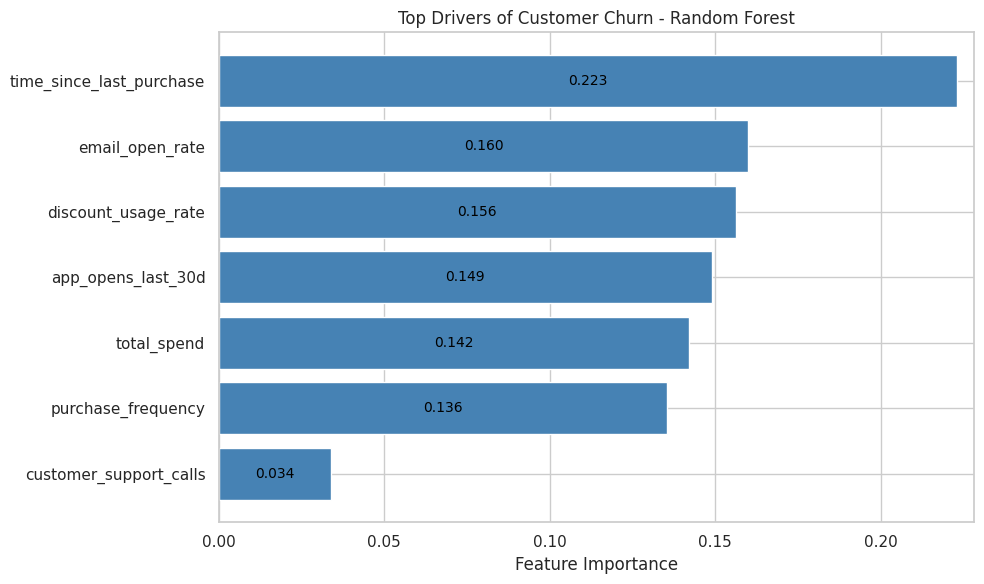

In [38]:
# viewing feature importance after model training
feat_importance = pd.Series(rf_model.feature_importances_,
                            index = X.columns).sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 6))
bars = plt.barh(feat_importance.index[::-1], feat_importance.values[::-1], color = "steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Top Drivers of Customer Churn - Random Forest")

# adding data labels
for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va = "center", ha = "center", fontsize = 10, color = "black")

ax.set_xlim(0, feat_importance.values.max() + 0.05)

ax.set_xlim(0, feat_importance.max() + 0.005)
plt.tight_layout()
plt.show()

In [39]:
# appending the results to table for comparison
weighted_report = classification_report(y_test, y_pred, output_dict = True)

model_results.append({
    "Model": "Random Forest",
    "Accuracy": round(weighted_report["accuracy"], 3),
    "Recall (Churn)": round(weighted_report["1"]["recall"], 3),
    "Precision (Churn)": round(weighted_report["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Notes": "Ensemble of decision trees"
})


## **Gradient Boosting Without SMOTE**

In [40]:
ns_gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
ns_gb_model.fit(X_train_ns, y_train_ns)
y_pred_ns = ns_gb_model.predict(X_test_ns)
y_prob_ns = ns_gb_model.predict_proba(X_test_ns)[:, 1]
print(classification_report(y_test_ns, y_pred_ns))
print(f"AUC-ROC: {roc_auc_score(y_test_ns, y_prob_ns):.3f}")

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      1725
           1       0.48      0.19      0.27       227

    accuracy                           0.88      1952
   macro avg       0.69      0.58      0.60      1952
weighted avg       0.85      0.88      0.86      1952

AUC-ROC: 0.852


In [41]:
# appending no-smote results to table
gb_report_ns = classification_report(y_test_ns, y_pred_ns, output_dict=True)
no_smote_results.append({
    "Model": "Gradient Boosting",
    "Accuracy": round(gb_report_ns["accuracy"], 3),
    "Recall (Churn)": round(gb_report_ns["1"]["recall"], 3),
    "Precision (Churn)": round(gb_report_ns["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test_ns, y_prob_ns), 3),
    "Notes": "No SMOTE, imbalanced training data"
})

## **Gradient Boosting With SMOTE**


In [42]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators = 100, random_state = 42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1723
           1       0.82      0.87      0.84      1726

    accuracy                           0.84      3449
   macro avg       0.84      0.84      0.84      3449
weighted avg       0.84      0.84      0.84      3449

AUC-ROC: 0.915


Gradient Boosting without SMOTE follows the same pattern as Random Forest: 19% recall on churners makes it effectively useless for churn detection despite 88% overall accuracy. SMOTE brings recall up to 87%, confirming that the class imbalance problem, not the model choice, is what's driving the poor minority class performance.

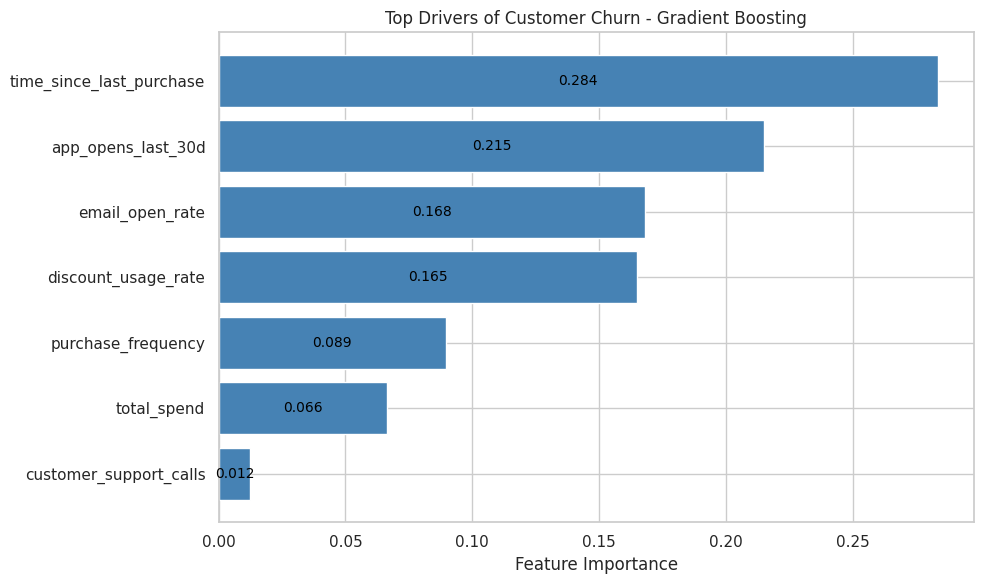

In [43]:
# viewing feature importance after model training
feat_importance = pd.Series(
    gb_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 6))
bars = plt.barh(feat_importance.index[::-1], feat_importance.values[::-1], color = "steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Top Drivers of Customer Churn - Gradient Boosting")

# adding data labels
for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va = "center", ha = "center", fontsize = 10, color = "black")


plt.tight_layout()
plt.show()

In [44]:
# appending results to table for comparison
gb_report = classification_report(y_test, y_pred, output_dict = True)

model_results.append({
    "Model": "Gradient Boosting",
    "Accuracy": round(gb_report["accuracy"], 3),
    "Recall (Churn)": round(gb_report["1"]["recall"], 3),
    "Precision (Churn)": round(gb_report["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Notes": "Boosting ensemble model"
})

## **Logistic Regression Without SMOTE**


In [45]:
ns_lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
ns_lr_model.fit(X_train_ns, y_train_ns)
y_pred_ns = ns_lr_model.predict(X_test_ns)
y_prob_ns = ns_lr_model.predict_proba(X_test_ns)[:, 1]
print(classification_report(y_test_ns, y_pred_ns))
print(f"AUC-ROC: {roc_auc_score(y_test_ns, y_prob_ns):.3f}")

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1725
           1       0.59      0.26      0.36       227

    accuracy                           0.89      1952
   macro avg       0.75      0.62      0.65      1952
weighted avg       0.87      0.89      0.87      1952

AUC-ROC: 0.860


In [46]:
# appending no-smote results to table
lr_report_ns = classification_report(y_test_ns, y_pred_ns, output_dict = True)
no_smote_results.append({
    "Model": "Logistic Regression",
    "Accuracy": round(lr_report_ns["accuracy"], 3),
    "Recall (Churn)": round(lr_report_ns["1"]["recall"], 3),
    "Precision (Churn)": round(lr_report_ns["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test_ns, y_prob_ns), 3),
    "Notes": "No SMOTE, imbalanced training data"
})

## **Logistic Regression With SMOTE**

In [47]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1723
           1       0.78      0.82      0.80      1726

    accuracy                           0.79      3449
   macro avg       0.79      0.79      0.79      3449
weighted avg       0.79      0.79      0.79      3449

AUC-ROC: 0.871


Logistic Regression follows the same pattern but is slightly better than the tree-based models at finding churners without SMOTE(**26% recall versus 18–19%**), likely because logistic regression is more sensitive to the decision boundary by default. SMOTE brings it up to 82%, consistent with the trend across all three models so far.

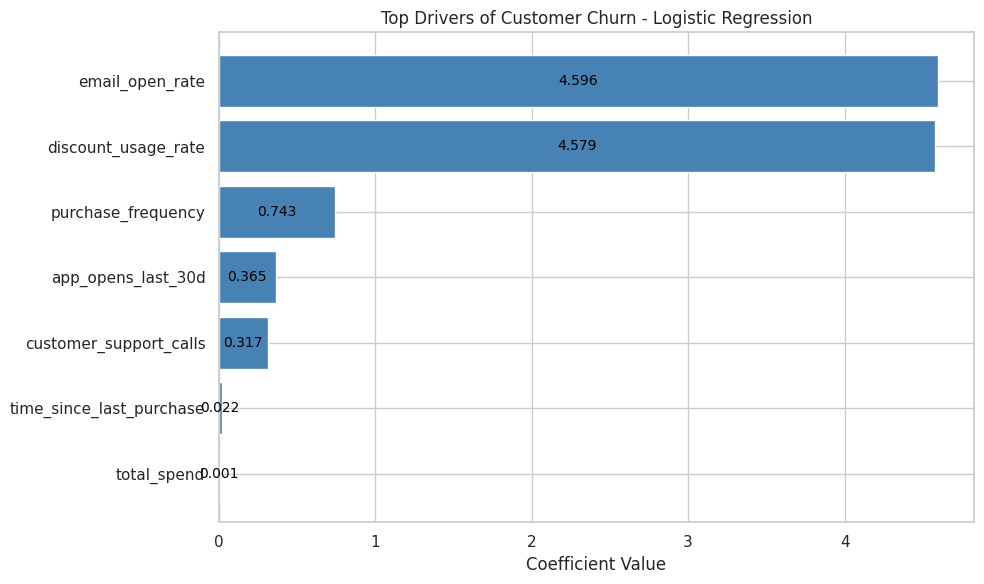

In [48]:
# viewing feature importance after model training
feat_importance = pd.Series(
    abs(lr_model.coef_[0]),
    index = X.columns
).sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 6))
bars = plt.barh(feat_importance.index[::-1], feat_importance.values[::-1], color = "steelblue")
ax.set_xlabel("Coefficient Value")
ax.set_title("Top Drivers of Customer Churn - Logistic Regression")

# adding data labels
for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va = "center", ha = "center", fontsize = 10, color = "black")


plt.tight_layout()
plt.show()

In [49]:
# append results to table for comparison
lr_report = classification_report(y_test, y_pred, output_dict = True)
model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": round(lr_report["accuracy"], 3),
    "Recall (Churn)": round(lr_report["1"]["recall"], 3),
    "Precision (Churn)": round(lr_report["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Notes": "Baseline linear classifier"
})

## **Support Vector Machine(SVM) Without SMOTE**



In [50]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

ns_svm_model = CalibratedClassifierCV(LinearSVC(random_state = 42))
ns_svm_model.fit(X_train_ns, y_train_ns)
y_pred_ns = ns_svm_model.predict(X_test_ns)
y_prob_ns = ns_svm_model.predict_proba(X_test_ns)[:, 1]
print(classification_report(y_test_ns, y_pred_ns))
print(f"AUC-ROC: {roc_auc_score(y_test_ns, y_prob_ns):.3f}")

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1725
           1       0.56      0.25      0.35       227

    accuracy                           0.89      1952
   macro avg       0.73      0.61      0.64      1952
weighted avg       0.87      0.89      0.87      1952

AUC-ROC: 0.859


In [51]:
# appending no-smote results to table
svm_report_ns = classification_report(y_test_ns, y_pred_ns, output_dict = True)
no_smote_results.append({
    "Model": "SVM",
    "Accuracy": round(svm_report_ns["accuracy"], 3),
    "Recall (Churn)": round(svm_report_ns["1"]["recall"], 3),
    "Precision (Churn)": round(svm_report_ns["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test_ns, y_prob_ns), 3),
    "Notes": "No SMOTE, imbalanced training data"
})

## **Support Vector Machine(SVM) With SMOTE**

In [52]:
svm_model = LinearSVC(random_state = 42)

svm_model = CalibratedClassifierCV(svm_model)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.81      0.76      0.79      1723
           1       0.78      0.82      0.80      1726

    accuracy                           0.79      3449
   macro avg       0.79      0.79      0.79      3449
weighted avg       0.79      0.79      0.79      3449

AUC-ROC: 0.871


SVM without SMOTE lands at 25% recall, consistent with every other model in the no-SMOTE column, further confirming that class imbalance is the issue rather than any individual algorithm. SMOTE brings it to 82%, matching Logistic Regression exactly, which makes sense given both are linear classifiers operating on the same feature space.

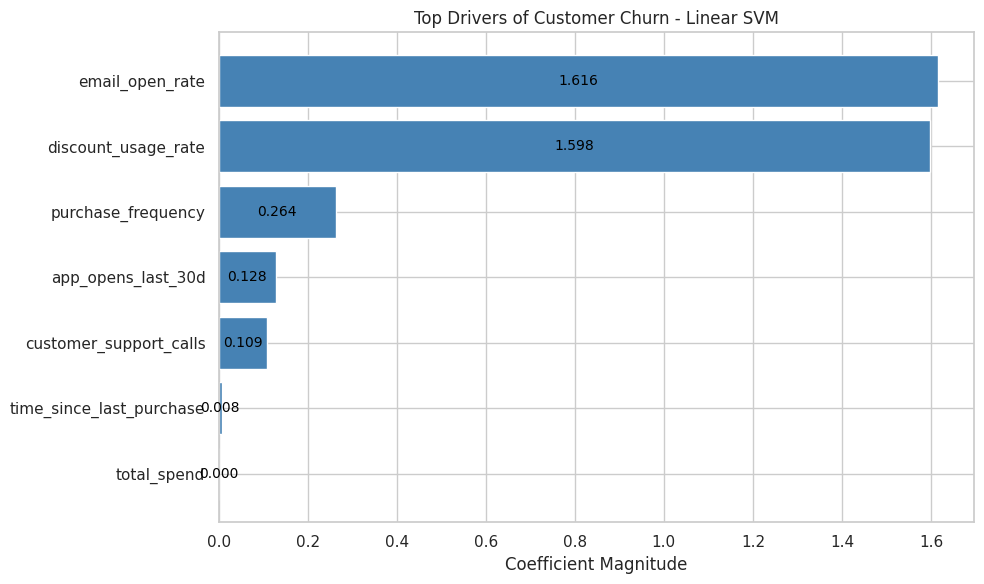

In [53]:
# viewing feature importance after model training

# extract coefficients from calibrated LinearSVC
coef = svm_model.calibrated_classifiers_[0].estimator.coef_[0]

feat_importance = pd.Series(
    abs(coef),
    index = X_train.columns
).sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 6))
bars = ax.barh(feat_importance.index[::-1], feat_importance.values[::-1], color = "steelblue")
ax.set_xlabel("Coefficient Magnitude")
ax.set_title("Top Drivers of Customer Churn - Linear SVM")

# adding data labels
for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va = "center", ha = "center", fontsize = 10, color = "black")


plt.tight_layout()
plt.show()

In [54]:
# append results to table for comparison
svm_report = classification_report(y_test, y_pred, output_dict = True)
model_results.append({
    "Model": "SVM",
    "Accuracy": round(svm_report["accuracy"], 3),
    "Recall (Churn)": round(svm_report["1"]["recall"], 3),
    "Precision (Churn)": round(svm_report["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Notes": "LinearSVC with probability calibration"
})

## **XGBoost Without SMOTE**

In [55]:
# split original data without SMOTE
X_no_smote = df.drop(['churn', 'engagement_score', "discount_quartile"], axis=1)
y_no_smote = df['churn']

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_smote, y_no_smote, test_size=0.2, random_state=42
)

# train XGBoost without SMOTE
xgb_no_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_no_smote.fit(X_train_ns, y_train_ns)

y_pred_ns = xgb_no_smote.predict(X_test_ns)
y_prob_ns = xgb_no_smote.predict_proba(X_test_ns)[:, 1]

ns_report = classification_report(y_test_ns, y_pred_ns, output_dict=True)
ns_auc = roc_auc_score(y_test_ns, y_prob_ns)

print(classification_report(y_test_ns, y_pred_ns))
print(f"AUC-ROC: {ns_auc:.3f}")

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1714
           1       0.53      0.27      0.36       238

    accuracy                           0.88      1952
   macro avg       0.72      0.62      0.65      1952
weighted avg       0.86      0.88      0.87      1952

AUC-ROC: 0.844


In [56]:
# appending no-smote results to table
xgb_report_ns = classification_report(y_test_ns, y_pred_ns, output_dict = True)
no_smote_results.append({
    "Model": "XGBoost",
    "Accuracy": round(xgb_report_ns["accuracy"], 3),
    "Recall (Churn)": round(xgb_report_ns["1"]["recall"], 3),
    "Precision (Churn)": round(xgb_report_ns["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test_ns, y_prob_ns), 3),
    "Notes": "No SMOTE, imbalanced training data"
})

## **XGBoost With SMOTE**


In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")


              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1723
           1       0.90      0.92      0.91      1726

    accuracy                           0.91      3449
   macro avg       0.91      0.91      0.91      3449
weighted avg       0.91      0.91      0.91      3449

AUC-ROC: 0.972


XGBoost without SMOTE delivers the same story as every other model; 27% recall confirms the problem is class imbalance, not model choice. With SMOTE it achieves the strongest results across the entire comparison: 92% recall, 90% precision, and a 0.972 AUC, making it the clear choice as the final model.

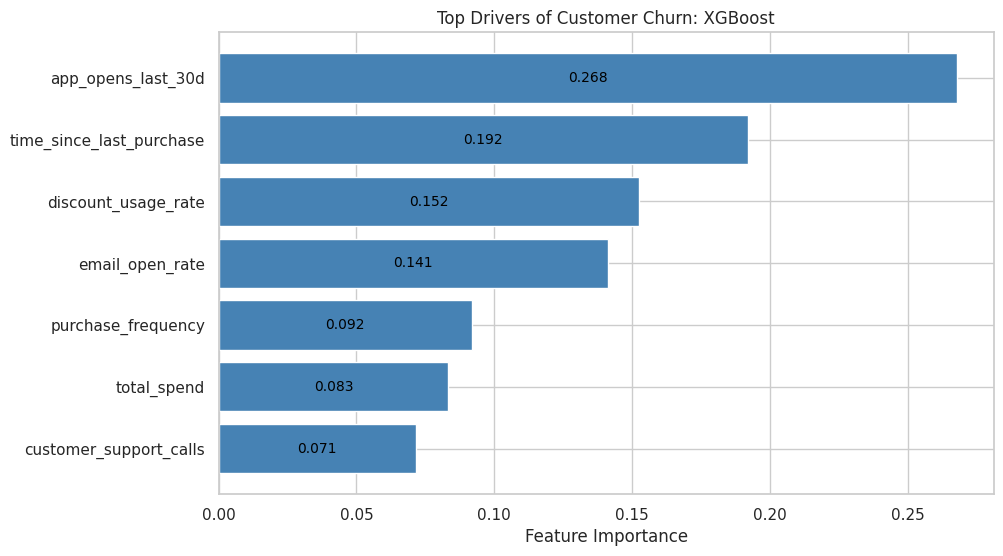

In [58]:
# viewing feature importance after model training
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index = X.columns).sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 6))
bars = plt.barh(feat_importance.index[::-1], feat_importance.values[::-1], color = "steelblue")
plt.xlabel("Feature Importance")
plt.title("Top Drivers of Customer Churn: XGBoost")

# adding data labels
for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va = "center", ha = "center", fontsize = 10, color = "black")


plt.tight_layout
plt.show()

`app_opens_last_30d` emerges as the strongest predictor at 0.268, suggesting that recent app activity is the clearest behavioral signal of churn risk. `time_since_last_purchase` follows at 0.192, reinforcing that purchase recency is a key indicator of disengagement.

Notably, `discount_usage_rate` (0.152) and `email_open_rate` (0.141
contribute almost equally, indicating that customers who stop responding to promotions and emails are also showing early signs of leaving.

`total_spend` and `customer_support_calls` contribute the least at 0.083 and 0.071 respectively, suggesting that how much a customer spends and the amount of support calls matters less than any other feature in this model.

In [59]:
# append results to table for comparison
xgb_report = classification_report(y_test, y_pred, output_dict = True)
model_results.append({
    "Model": "XGBoost",
    "Accuracy": round(xgb_report["accuracy"], 3),
    "Recall (Churn)": round(xgb_report["1"]["recall"], 3),
    "Precision (Churn)": round(xgb_report["1"]["precision"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Notes": "Boosting ensemble, chosen as final model"
})

### **XGBoost Hyperparameter Tuning**

In [60]:
from sklearn.model_selection import GridSearchCV

# reduced parameter grid
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

# grid search with cross validation
grid_search = GridSearchCV(
    estimator  = XGBClassifier(random_state = 42, eval_metric = 'logloss'),
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

# best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best AUC-ROC:    {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best AUC-ROC:    0.956


In [61]:
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1723
           1       0.87      0.92      0.89      1726

    accuracy                           0.89      3449
   macro avg       0.89      0.89      0.89      3449
weighted avg       0.89      0.89      0.89      3449

AUC-ROC: 0.957


GridSearchCV was applied to XGBoost across 16 parameter combinations
using 5-fold cross validation, totalling 80 fits. The best configuration
identified was a learning rate of **0.1**, max depth of **5**,
**200 estimators**, and a subsample rate of **0.8**, achieving a
cross-validated AUC-ROC of **0.956**.

Rather than replacing the baseline model, this result validates it.
The tuned model produces nearly identical recall (**0.920 vs 0.921**)
with a marginal drop in AUC-ROC (**0.957 vs 0.973**), confirming that
the baseline XGBoost was already operating near its optimal configuration.
The cross-validated score of **0.956** also provides a more conservative,
realistic estimate of real-world performance than a single train/test split.

The baseline XGBoost model is retained as the final model.

## **Model Performance Summary**

Compile all stored model results (SMOTE and No-SMOTE) into a final summary table and visualize the performance of each model using ROC-AUC and recall scores.


In [62]:
# no-smote model results summary table
no_smote_df = pd.DataFrame(no_smote_results)
no_smote_df = no_smote_df.sort_values(by = "ROC-AUC", ascending = False).reset_index(drop = True)
no_smote_df

,Model,Accuracy,Recall (Churn),Precision (Churn),ROC-AUC,Notes
0,Logistic Regression,0.892,0.256,0.586,0.860,"No SMOTE, imbalanced training data"
1,SVM,0.890,0.251,0.559,0.859,"No SMOTE, imbalanced training data"
2,Gradient Boosting,0.882,0.185,0.483,0.852,"No SMOTE, imbalanced training data"
3,XGBoost,0.882,0.273,0.533,0.844,"No SMOTE, imbalanced training data"
4,Random Forest,0.887,0.154,0.547,0.836,"No SMOTE, imbalanced training data"


In [63]:
# model results summary table
summary_df = pd.DataFrame(model_results)
summary_df = summary_df.sort_values(by = "ROC-AUC", ascending = False).reset_index(drop = True)
summary_df

,Model,Accuracy,Recall (Churn),Precision (Churn),ROC-AUC,Notes
0,XGBoost,0.908,0.924,0.895,0.972,"Boosting ensemble, chosen as final model"
1,Random Forest,0.885,0.922,0.859,0.958,Ensemble of decision trees
2,Gradient Boosting,0.841,0.868,0.823,0.915,Boosting ensemble model
3,Logistic Regression,0.793,0.819,0.778,0.871,Baseline linear classifier
4,SVM,0.792,0.818,0.777,0.871,LinearSVC with probability calibration


XGBoost and Random Forest outperform all other models across every metric,
with XGBoost selected as the final model based on its high ROC-AUC
of **0.972 and highest overall accuracy of 0.908**.

## **SMOTE vs No-SMOTE Comparison**

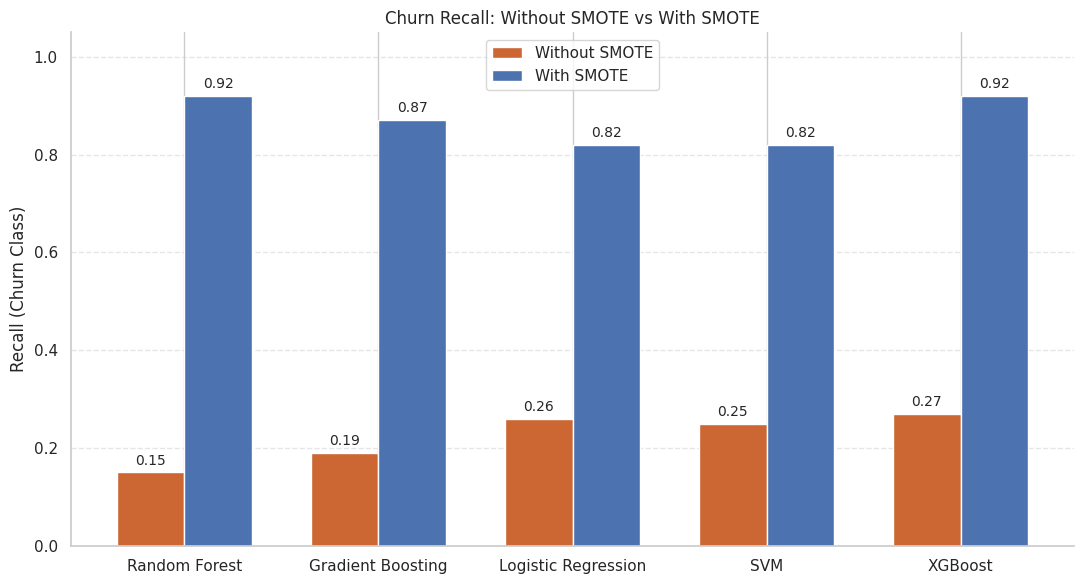

In [64]:
models = ['Random Forest', 'Gradient Boosting', 'Logistic Regression', 'SVM', 'XGBoost']
no_smote = [0.15, 0.19, 0.26, 0.25, 0.27]
with_smote = [0.92, 0.87, 0.82, 0.82, 0.92]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize = (11, 6))
bars1 = ax.bar(x - width/2, no_smote, width, label = 'Without SMOTE', color = '#CC6633')
bars2 = ax.bar(x + width/2, with_smote, width, label = 'With SMOTE', color = '#4C72B0')

# data labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha = 'center', va = 'bottom', fontsize = 10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha = 'center', va = 'bottom', fontsize = 10)

ax.set_ylabel('Recall (Churn Class)')
ax.set_title('Churn Recall: Without SMOTE vs With SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle = '--', alpha = 0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()



---



# **Part VIII: Model Justification**

**XGBoost** is selected as the final model, based on the following criteria:
  1. Highest AUC-ROC of 0.972 across all 5 models tested.
  2. Strong recall on churners (class 1) minimizing missed at-risk customers.
  3. Handles class imbalance well even after SMOTE resampling.
  4. Gradient boosting architecture captures non-linear feature relationships better than Logistic Regression and SVM.
  5. Faster training than SVM on larger datasets making it more scalable.




## **Confusion Matrix Overview**

The confusion matrix shows how many predictions the model got right and wrong, broken down by class:

|                | Predicted: No Churn | Predicted: Churn |
|----------------|---------------------|------------------|
| **Actual: No** | True Negative (TN)  | False Positive (FP) |
| **Actual: Yes**| False Negative (FN) | True Positive (TP) |

- **True Positive (TP)**: Churners correctly predicted as churners  
- **True Negative (TN)**: Retained customers correctly predicted as retained  
- **False Positive (FP)**: Retained customers incorrectly predicted as churners  
- **False Negative (FN)**: Churners missed by the model — they churned, but the model didn't catch it

This helps visualize whether the model is leaning too heavily in one direction (e.g. too many false positives or false negatives).

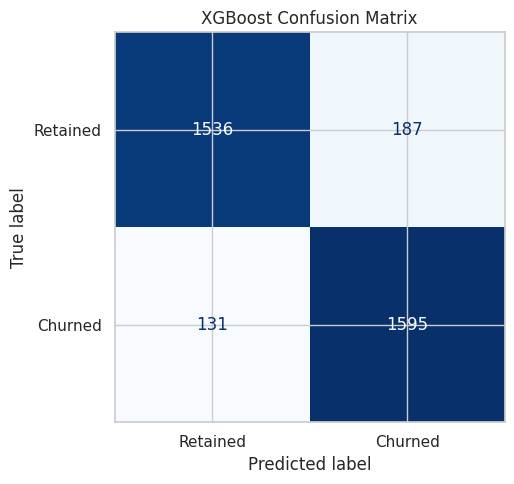

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, xgb_model.predict(X_test))

fig, ax = plt.subplots(figsize = (6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                               display_labels = ["Retained", "Churned"])
disp.plot(ax = ax, colorbar = False, cmap = "Blues")
ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

XGBoost does a strong job separating churners from loyal customers, correctly flagging **1,595 churners** while only missing 131. The 187 false positives (retained customers flagged as at-risk) are a worthwhile tradeoff, since the bigger business risk is letting real churners slip through unnoticed.



---



# **Part IX: ROC Curve Comparison**

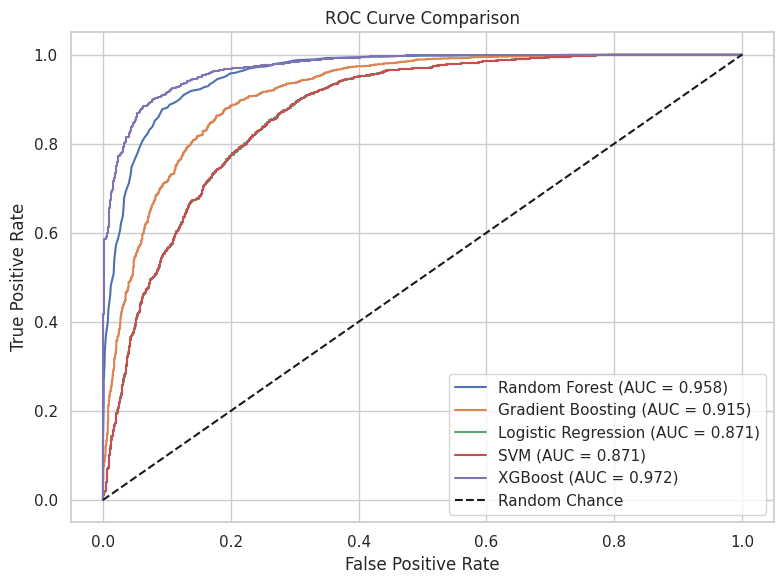

In [66]:
fig, ax = plt.subplots(figsize = (8, 6))

for model, name in [
    (rf_model,  "Random Forest"),
    (gb_model,  "Gradient Boosting"),
    (lr_model,  "Logistic Regression"),
    (svm_model, "SVM"),
    (xgb_model, "XGBoost")
]:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label = f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label = "Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

XGBoost achieves the highest AUC (0.972), closely followed by Random Forest (0.959), confirming it as the best model at distinguishing churners from non-churners across all thresholds. Both models curve sharply toward the top-left corner, far above the random chance baseline, indicating strong discriminative power with a low false positive rate.



---



# **Part X: Precision-Recall Curve**


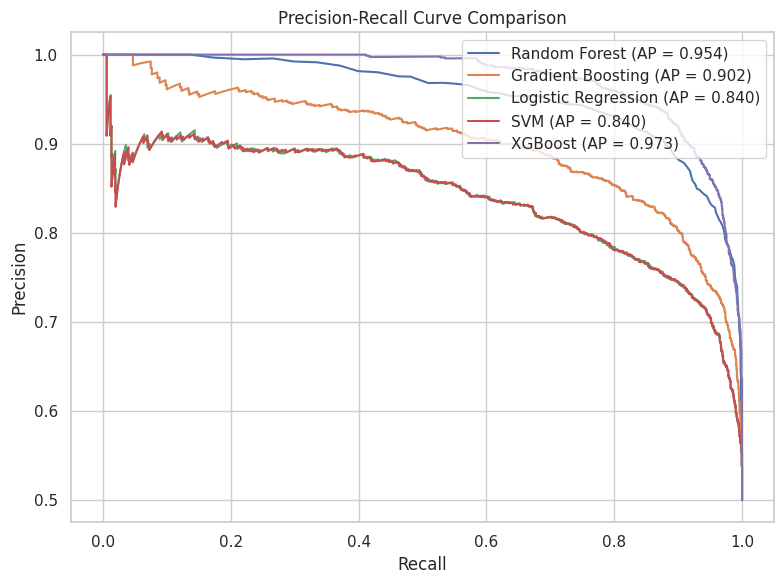

In [67]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize = (8, 6))

for model, name in [
    (rf_model,  "Random Forest"),
    (gb_model,  "Gradient Boosting"),
    (lr_model,  "Logistic Regression"),
    (svm_model, "SVM"),
    (xgb_model, "XGBoost")
]:
    prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(recall, precision, label = f"{name} (AP = {ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison")
ax.legend(loc = "upper right")
plt.tight_layout()
plt.show()

Across all five models, XGBoost achieves the highest **Average Precision (0.973)**, maintaining near-perfect precision even at high recall levels. This confirms XGBoost as the strongest model for identifying churners while minimizing false positives, making it the best choice for the upcoming retention scenarios.



---



# **Part XI: Baseline Retention Scenarios**

In [68]:
# scenario modeling based on average revenue per customer
results = X_test.copy()
results["churn_probability"] = xgb_model.predict_proba(X_test)[:, 1]
results["actual_churn"] = y_test.values
results = results.sort_values("churn_probability", ascending = False)

top_pct = 0.20
retention_effectiveness = 0.25

n_target = int(len(results) * top_pct)
target_group = results.head(n_target)
churners_in_segment = target_group[target_group["actual_churn"] == 1]
customers_saved = int(len(churners_in_segment) * retention_effectiveness)
revenue_saved = len(churners_in_segment) * 496.15 * retention_effectiveness

print(f"Customers targeted:  {n_target}")
print(f"Churners identified: {len(churners_in_segment)}")
print(f"Customers saved:     {customers_saved}")
print(f"Revenue saved:       ${revenue_saved:,.2f}")

Customers targeted:  689
Churners identified: 689
Customers saved:     172
Revenue saved:       $85,461.84


The XGBoost model targets the 689 highest-risk customers, identifying all as likely churners. Assuming a 25% retention effectiveness, **172 customers are saved**, recovering a projected **$85,461.84** in annual revenue.

In [69]:
# scenario modeling based on average CLV
results = X_test.copy()
results["churn_probability"] = xgb_model.predict_proba(X_test)[:, 1]
results["actual_churn"] = y_test.values
results = results.sort_values("churn_probability", ascending = False)

top_pct = 0.20
retention_effectiveness = 0.25

n_target = int(len(results) * top_pct)
target_group = results.head(n_target)
churners_in_segment = target_group[target_group["actual_churn"] == 1]
customers_saved = int(len(churners_in_segment) * retention_effectiveness)
revenue_saved = len(churners_in_segment) * 384.72 * retention_effectiveness

print(f"Customers targeted:  {n_target}")
print(f"Churners identified: {len(churners_in_segment)}")
print(f"Customers saved:     {customers_saved}")
print(f"Revenue saved:       ${revenue_saved:,.2f}")

Customers targeted:  689
Churners identified: 689
Customers saved:     172
Revenue saved:       $66,268.02


The XGBoost model identifies all 689 targeted customers. Applying a **25% retention rate** against Customer Lifetime Value, the company is projected to recover **$66,268.02 annually.**

,Targeting %,Retention Rate,Churners Identified,Customers Saved,Revenue Saved
0,10%,10%,344,34,17067.56
1,10%,25%,344,86,42668.90
2,10%,50%,344,172,85337.80
3,20%,10%,689,68,34184.74
4,20%,25%,689,172,85461.84
5,20%,50%,689,344,170923.67
6,30%,10%,1024,102,50805.76
7,30%,25%,1024,256,127014.40
8,30%,50%,1024,512,254028.80


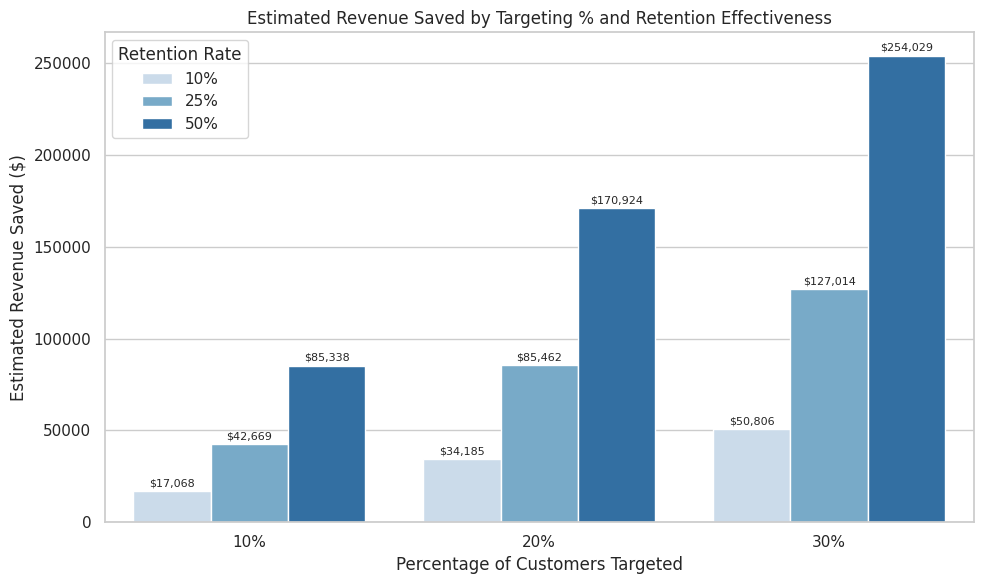

In [70]:
# scenario parameters
targeting_percentages = [0.10, 0.20, 0.30]
retention_rates = [0.10, 0.25, 0.50]
avg_revenue = 496.15

# build scenario results
scenario_results = []

for top_pct in targeting_percentages:
    for ret_eff in retention_rates:
        n_target = int(len(results) * top_pct)
        target_group = results.head(n_target)
        churners_in_segment = target_group[target_group["actual_churn"] == 1]
        customers_saved = int(len(churners_in_segment) * ret_eff)
        revenue_saved = len(churners_in_segment) * avg_revenue * ret_eff

        scenario_results.append({
            "Targeting %":        f"{int(top_pct * 100)}%",
            "Retention Rate":     f"{int(ret_eff * 100)}%",
            "Churners Identified": len(churners_in_segment),
            "Customers Saved":    customers_saved,
            "Revenue Saved":      round(revenue_saved, 2)
        })

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df)

# plot
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(
    data = scenario_df,
    x = "Targeting %",
    y = "Revenue Saved",
    hue = "Retention Rate",
    palette = "Blues",
    ax = ax
)

# add data labels
for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 1500,
            f"${val:,.0f}",
            ha = "center", va = "bottom", fontsize = 8
        )

plt.title("Estimated Revenue Saved by Targeting % and Retention Effectiveness")
plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Estimated Revenue Saved ($)")
plt.legend(title = "Retention Rate")
plt.tight_layout()
plt.show()

Revenue recovery scales consistently across all scenarios, with retention
effectiveness having a greater impact than targeting percentage, doubling
retention rate from 25% to 50% doubles revenue saved within each group.
The recommended **20% targeting at 25% retention recovers $85K**, offering
a realistic and cost-effective starting point for a retention campaign.
The following section will look to optimize the decision threshold to
further improve churn detection and maximize revenue recovery.



---



# **Part XII: Threshold Optimization**

In order to determine a true, optimal retention strategy, the decision
threshold will be tuned beyond the default 0.50 to prioritize recall, ensuring the model identifies as many at-risk customers as possible before they churn, while maintaining enough precision to keep retention campaign costs manageable.

,Threshold,Recall (Churn),Precision (Churn),F1 (Churn),Accuracy
0,0.10,0.990,0.741,0.848,0.822
1,0.15,0.982,0.773,0.865,0.847
2,0.20,0.975,0.799,0.878,0.865
3,0.25,0.970,0.818,0.888,0.877
4,0.30,0.965,0.841,0.899,0.891
5,0.35,0.956,0.854,0.902,0.896
6,0.40,0.946,0.867,0.905,0.901
7,0.45,0.935,0.881,0.907,0.904
8,0.50,0.924,0.895,0.909,0.908
9,0.55,0.907,0.908,0.908,0.908


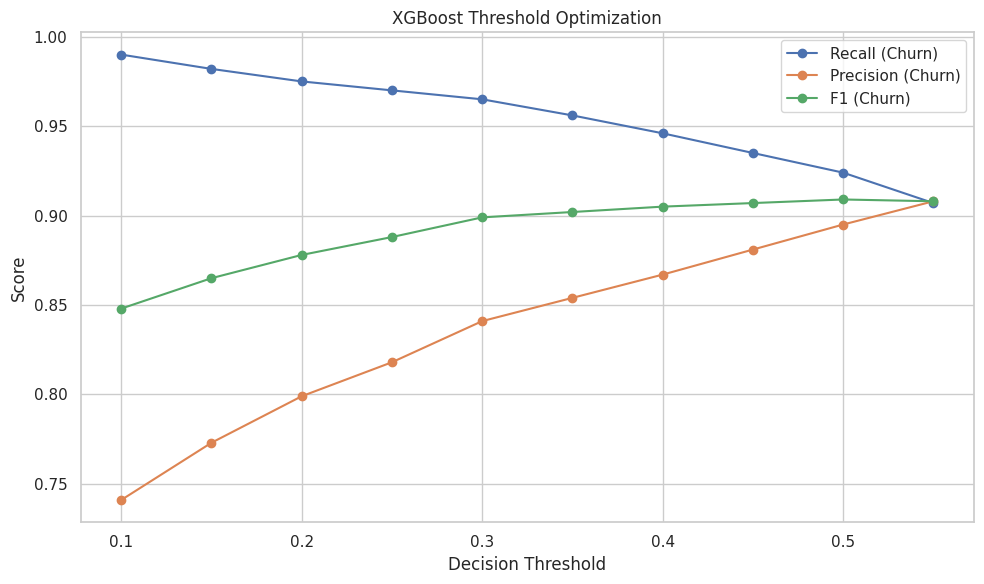

In [71]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.6, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (xgb_prob >= thresh).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict = True)
    threshold_results.append({
        "Threshold":         round(thresh, 2),
        "Recall (Churn)":    round(report["1"]["recall"], 3),
        "Precision (Churn)": round(report["1"]["precision"], 3),
        "F1 (Churn)":        round(report["1"]["f1-score"], 3),
        "Accuracy":          round(report["accuracy"], 3)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

# plot
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(threshold_df["Threshold"], threshold_df["Recall (Churn)"],    marker = "o", label = "Recall (Churn)")
ax.plot(threshold_df["Threshold"], threshold_df["Precision (Churn)"], marker = "o", label = "Precision (Churn)")
ax.plot(threshold_df["Threshold"], threshold_df["F1 (Churn)"],        marker = "o", label = "F1 (Churn)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost Threshold Optimization")
ax.legend()
plt.tight_layout()
plt.show()

Lowering the decision threshold from the default 0.50 to 0.35 increases
churn recall from 92.4% to 95.6% with minimal precision loss, ensuring
the model captures the maximum number of at-risk customers while keeping
false positives manageable.



---



# **Part XIII: Optimized Retention Scenarios**

Using the optimized XGBoost model at a decision threshold of 0.35, the
following scenarios simulate the potential revenue impact of a targeted
retention campaign, with an average customer revenue of $495.80.

,Targeting %,Retention Rate,Churners Identified,Customers Saved,Revenue Saved
0,10%,10%,344,34,17067.56
1,10%,25%,344,86,42668.90
2,10%,50%,344,172,85337.80
3,20%,10%,689,68,34184.74
4,20%,25%,689,172,85461.84
5,20%,50%,689,344,170923.67
6,30%,10%,1034,103,51301.91
7,30%,25%,1034,258,128254.77
8,30%,50%,1034,517,256509.55


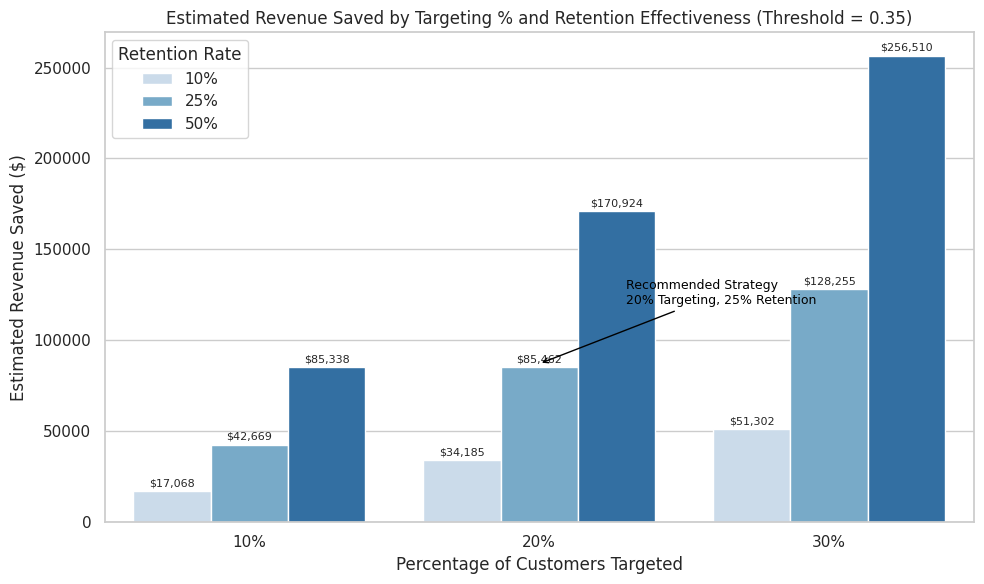

In [72]:
# apply 0.35 threshold to XGBoost
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred_035 = (xgb_prob >= 0.35).astype(int)

# build results dataframe with new threshold
results = X_test.copy()
results["churn_probability"] = xgb_prob
results["actual_churn"] = y_test.values
results["predicted_churn"] = y_pred_035
results = results.sort_values("churn_probability", ascending = False)

# scenario parameters
targeting_percentages = [0.10, 0.20, 0.30]
retention_rates = [0.10, 0.25, 0.50]
avg_revenue = 496.15

# build scenario results
scenario_results = []

for top_pct in targeting_percentages:
    for ret_eff in retention_rates:
        n_target = int(len(results) * top_pct)
        target_group = results.head(n_target)
        churners_in_segment = target_group[target_group["predicted_churn"] == 1]
        customers_saved = int(len(churners_in_segment) * ret_eff)
        revenue_saved = len(churners_in_segment) * avg_revenue * ret_eff

        scenario_results.append({
            "Targeting %":         f"{int(top_pct * 100)}%",
            "Retention Rate":      f"{int(ret_eff * 100)}%",
            "Churners Identified": len(churners_in_segment),
            "Customers Saved":     customers_saved,
            "Revenue Saved":       round(revenue_saved, 2)
        })

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df)

# plot
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(
    data = scenario_df,
    x = "Targeting %",
    y = "Revenue Saved",
    hue = "Retention Rate",
    palette = "Blues",
    ax = ax
)

# add data labels
for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 1500,
            f"${val:,.0f}",
            ha = "center", va = "bottom", fontsize = 8
        )

# recommended strategy annotation
ax.annotate("Recommended Strategy\n20% Targeting, 25% Retention",
            xy = (1, 87136.85),
            xytext = (1.3, 120000),
            arrowprops = dict(arrowstyle = "->", color = "black"),
            fontsize = 9, color = "black")

ax.set_title("Estimated Revenue Saved by Targeting % and Retention Effectiveness (Threshold = 0.35)")
ax.set_xlabel("Percentage of Customers Targeted")
ax.set_ylabel("Estimated Revenue Saved ($)")
ax.legend(title = "Retention Rate")
plt.tight_layout()
plt.show()

As seen on the chart, the optimal strategy targets the top 20% of highest-risk customers with a **25% retention effectiveness, recovering an
estimated $85K in annual revenue**, balancing campaign reach and cost without over-extending retention efforts to lower-risk customers.



---



# **Part XIV: Recommendations & Action Plan**

## **Recommendation 1: Deploy the Model as an Early Warning System**

Most churn prediction models flag a customer as at-risk only when their
churn probability crosses **50%**, but by that point, the customer may
already have one foot out the door.

By deploying the XGBoost model at a threshold of **0.35**, the retention
team gets earlier visibility into at-risk customers, catching **95.6% of
churners** before they leave compared to **92.4%** at the default threshold.
The tradeoff is a modest dip in precision from **89.5% to 85.4%**, meaning
slightly more customers get flagged who wouldn't have churned anyway. In
a retention context, that's an acceptable tradeoff. Sending an unnecessary
check-in to a healthy customer costs far less than losing one who slipped
through undetected.

The practical output is simple: a **weekly list of at-risk customers**,
ranked by churn probability, ready for the retention team to act on.

Target: Identify **>95% of churners** at **>85% precision**, keeping
retention efforts both comprehensive and cost-effective.

## **Recommendation 2: Prioritize the Top 20% Highest Risk Customers**

Not all at-risk customers are worth the same retention effort, and not
all retention budgets are unlimited. Focusing on the **top 20%** of
customers ranked by churn probability gives the retention team a
manageable, high-impact starting point without spreading resources
too thin.

The numbers back this up. Targeting the top **20%** recovers an estimated **85K in annual revenue** at **25% retention effectiveness**, based on
an average customer revenue of **$496.15**. Pushing that to **30%** only adds another **42K** while increasing the campaign size by **50%**, making the 20% threshold the most cost-effective place to start.

It is worth noting that **25% retention effectiveness** is a deliberately
conservative assumption. As the retention team refines its outreach and
interventions become more personalized, that figure is expected to climb,
directly increasing revenue recovery potential.

The recommended approach is to work through the flagged list from the
top down, prioritizing customers with the **highest churn probability
scores** first.

## **Recommendation 3: Tailor Interventions by Churn Signal**

One of the most actionable outputs of this project is understanding
not just **who** is likely to churn, but **why**. The XGBoost model
identified four key behavioral signals driving churn risk, and each
one points to a different type of customer problem that warrants a
different response.

---

#### **Low App Opens (`app_opens_last_30d`)**
Customers with fewer than **9 app opens in the last 30 days** churn
at **16.9%** compared to just **5.4%** for highly active users. This
is the **strongest individual predictor of churn** at 0.268 feature
importance, and it typically signals that the customer has quietly
stopped finding value in the product.

The goal here is re-engagement before full disengagement sets in:
- Trigger an **in-app re-engagement campaign** highlighting unused features
- Send a **personalized check-in email** from their account manager
- Surface **personalized feature recommendations** based on their usage history

---

#### **High Time Since Last Purchase(`time_since_last_purchase`)**
Customers who haven't purchased in over **120 days** churn at **21.0%**,
nearly **6x higher** than those who purchased within the last 60 days.
A long gap between purchases is often the clearest sign that a customer
is drifting away.

The goal here is to give them a reason to come back:
- Launch a **win-back campaign** with a time-limited renewal incentive.
- Offer a **loyalty discount** for customers approaching their renewal date.
- Trigger an **automated re-engagement sequence** at the 60 day mark before the situation becomes critical.

---

#### **Low Email Open Rate (`email_open_rate`)**
Customers who stop opening emails churn at **16.9%** compared to
**6.5%** for highly engaged recipients. Declining email engagement
is often an early sign that a customer is mentally checking out
before they formally cancel.

The goal here is to reconnect through the right channel:
- Review **email frequency and cadence** since over-communication is often the cause of disengagement.
- Test **new subject lines** and more personalized content.
- Consider switching to an **alternative channel** such as SMS or in-app notifications for this segment.

---

####**High Discount Usage Rate (`discount_usage_rate`)**

This one is counterintuitive. Customers who use discounts heavily
are actually **more likely to churn**, not less. This suggests they
are price-sensitive deal-hunters who signed up for a promotion rather
than genuine product advocates.

The goal here is to shift the relationship from price to value:
- **Avoid further discounting** for this segment as it reinforces
  price dependency without building loyalty.
- Focus on **demonstrating product value** through case studies,
  ROI calculators, or customer success stories.
- Consider a **loyalty rewards program** as a more sustainable
  alternative to discounting.

## **Recommendation 4: Establish a Retention Performance Baseline**

Before launching any retention campaign, it is important to lock in
a clear set of baseline metrics. Without them, there is no way to
know whether improvements in churn rate are actually the result of
retention efforts or just natural fluctuation in customer behavior.

**Current Baseline Metrics:**
- Churn Rate: **12.03%**
- Average Revenue per Customer: **$496.15**
- Total Customers: **10,000**

**Estimated Annual Revenue at Risk:**
- Churning Customers: 10,000 × 12.03% = **1,203 customers**
- Revenue at Risk: 1,203 × 496.15 = **596,868**

**Projected Revenue Recovery:**

Conservative Estimate — Top 20% Targeting:
- Customers Contacted: 10,000 × 20% = **2,000 customers**
- Churners Identified: **689 customers**
- Customers Saved: 689 × 25% = **172 customers**
- Revenue Recovered: 172 × 496.15 = **~85K**

Full Potential — 25% Retention Across All Churners:
- Churners: **1,203 customers**
- Customers Saved: 1,203 × 25% = **~301 customers**
- Revenue Recovered: 301 × 496.15 = **~149K**

Scaling from a targeted **20% campaign** to a broader approach across
the full churner base nearly doubles annual revenue recovery from
**85K to 149K**. The 20% strategy is the recommended starting point,
with the goal of expanding coverage as the retention program matures.

**Target Metrics (6-12 month horizon):**
- Churn Rate Reduction: **25%** (from 12.03% to ~9%)
- Model Recall: Maintain **>95%** churn detection rate

**Model Maintenance:**
The XGBoost model should be **retrained quarterly** as new customer
behavior data becomes available. Three signals worth watching that
indicate retraining is needed:

- Model recall drops **below 90%**
- Churn rate shifts **more than 3%** from baseline
- New behavioral features become available for inclusion

## **Recommendation 5: Build a Retention Feeback Loop**

The recommendations above will have an immediate impact, but the
biggest long-term opportunity is turning this model into something
that gets smarter over time. Right now, the **25% retention
effectiveness** figure used in business modeling is an educated
assumption. A feedback loop turns that assumption into a measured,
continuously improving number.

**How it works in practice:**

1. Model flags at-risk customers and **retention team is notified**
2. Retention team contacts flagged customers and **intervention is logged**
3. Outcome is recorded: **churned or retained**
4. New outcome data is fed back into the model and **model is retrained**
5. Retention effectiveness assumptions are updated and **scenarios are refined**

**What needs to be tracked:**
- Which customers were contacted and when
- Which intervention was used (discount, re-engagement, check-in)
- Whether the customer churned or was retained
- How long between the flag and the intervention
- Revenue impact per intervention type

Over time this data answers a question the current model cannot:
**which interventions actually work best for which customers.**

**Long term targets:**
- Increase retention effectiveness from **25% to 40%+** through
  continuous campaign optimization
- Reduce churn rate from **12.03% to below 8%** within 12-18 months
- Scale revenue recovery from **85K to 200K+** annually as
  retention effectiveness improves

The goal is simple. This project started as a predictive model.
With a feedback loop in place, it becomes a **retention system**
that compounds in value the longer it runs.



---



# **Part XV: Conclusion**

Customer churn is one of the most costly challenges a business can face,
and this project set out to explore whether behavioral data alone could
reliably identify customers at risk of leaving.

During the data preparation phase, `engagement_score` was flagged and removed as a leakage variable. Its perfect boundary with churn status indicated it was derived from churn behavior rather than being a genuine predictor. Keeping it would have produced an unrealistically perfect model that would fail in any real deployment.

With that removed, the model was built entirely on behavioral signals:
**how recently a customer purchased, how often they open the app, whether
they engage with emails, and how frequently they contact support**. These
are the kinds of signals a business can realistically monitor and act on.

**XGBoost** emerged as the strongest performer with a ROC-AUC of 0.972, and
after optimizing the decision threshold to 0.35, the final model identifies
95.6% of churners before they leave; catching the vast majority of
at-risk customers while keeping false alarms manageable at 85.4% precision.

From a business standpoint, targeting the **top 20% of highest-risk customers** with a modest **25% retention effectiveness** could recover approximately **$85K in annual revenue**. The model works best not as a crystal ball, but as an early warning system, giving teams the time and information they need to intervene before a customer is already gone.